# Exact paper-method reproduction for the continuum ROM

## Purpose

This notebook reproduces and critically evaluates the continuum
coarse-graining, POD and neural-surrogate method described by Plath
et al. It compares paper-style uncentred POD with the previously
selected mean-centred ROM and evaluates both on the same ten external
test parameters.

The notebook investigates POD truncation, neural-network architecture,
coefficient scaling, training-set size, retained rank, physical
plausibility and deterministic reproducibility. No raw particle
trajectory is read, and no result from Notebooks 12 or 13 is modified.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import sys

import joblib
import matplotlib
import numpy as np
import pandas as pd
import sklearn
import torch


def find_repository_root(start):
    """Find the repository without assuming Jupyter's start directory."""
    start = Path(start).resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "notebooks").is_dir()
            and (candidate / "data").is_dir()
            and (candidate / "results").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the repository root."
    )


REPO_ROOT = find_repository_root(Path.cwd())

DATASET_PATH = (
    REPO_ROOT
    / "data"
    / "processed"
    / "cg_phi_small_dataset.npz"
)

ROM_MANIFEST_PATH = (
    REPO_ROOT
    / "results"
    / "tables"
    / "cg_phi_rom_reproducibility_manifest.json"
)

TABLE_DIRECTORY = (
    REPO_ROOT
    / "results"
    / "tables"
    / "exact_paper_method_reproduction"
)

FIGURE_DIRECTORY = (
    REPO_ROOT
    / "results"
    / "figures"
    / "exact_paper_method_reproduction"
)

TABLE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)


environment_summary = pd.DataFrame(
    {
        "item": [
            "Repository root",
            "Python",
            "Platform",
            "NumPy",
            "pandas",
            "scikit-learn",
            "PyTorch",
            "Matplotlib",
        ],
        "value": [
            str(REPO_ROOT),
            sys.version.split()[0],
            platform.platform(),
            np.__version__,
            pd.__version__,
            sklearn.__version__,
            torch.__version__,
            matplotlib.__version__,
        ],
    }
)

display(environment_summary)

print("\nRequired inputs:")

input_audit = pd.DataFrame(
    {
        "input": [
            "Continuum dataset",
            "ROM reproducibility manifest",
        ],
        "path": [
            str(DATASET_PATH),
            str(ROM_MANIFEST_PATH),
        ],
        "exists": [
            DATASET_PATH.is_file(),
            ROM_MANIFEST_PATH.is_file(),
        ],
    }
)

display(input_audit)

assert input_audit["exists"].all()

print(
    "\nInitial Notebook 14 preflight passed:",
    True,
)

,item,value
0,Repository root,/Users/rallen/Documents/msc-rom-particle-systems
1,Python,3.12.1
2,Platform,macOS-15.7.5-x86_64-i386-64bit
3,NumPy,1.26.4
4,pandas,3.0.3
5,scikit-learn,1.9.0
6,PyTorch,2.2.2
7,Matplotlib,3.11.0



Required inputs:


,input,path,exists
0,Continuum dataset,/Users/rallen/Documents/msc-rom-particle-syste...,True
1,ROM reproducibility manifest,/Users/rallen/Documents/msc-rom-particle-syste...,True



Initial Notebook 14 preflight passed: True


In [2]:
def sha256_file(path, chunk_size=1024**2):
    """Return the SHA-256 digest of a file."""
    digest = hashlib.sha256()

    with Path(path).open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)

    return digest.hexdigest()


with ROM_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    rom_manifest = json.load(handle)


package_audit_records = []

for model_name in [
    "rank_4_rom",
    "rank_6_rom",
]:
    record = rom_manifest[model_name]

    package_path = (
        REPO_ROOT
        / record["path"]
    )

    observed_hash = (
        sha256_file(package_path)
        if package_path.is_file()
        else None
    )

    package_audit_records.append(
        {
            "model": model_name,
            "rank": record["rank"],
            "path": str(package_path),
            "exists": package_path.is_file(),
            "expected_sha256": record["sha256"],
            "observed_sha256": observed_hash,
            "hash_matches": (
                observed_hash
                == record["sha256"]
            ),
        }
    )


package_audit = pd.DataFrame(
    package_audit_records
)

display(
    package_audit[
        [
            "model",
            "rank",
            "path",
            "exists",
            "hash_matches",
        ]
    ]
)

print(
    "Manifest source notebook:",
    rom_manifest["notebook"],
)

print(
    "Recorded training/test cases:",
    rom_manifest["training_case_count"],
    rom_manifest["test_case_count"],
)

print(
    "Recorded candidate ranks:",
    rom_manifest["candidate_ranks"],
)


assert (
    rom_manifest["processed_dataset"]
    == str(
        DATASET_PATH.relative_to(
            REPO_ROOT
        )
    )
)

assert package_audit["exists"].all()
assert package_audit["hash_matches"].all()
assert rom_manifest["training_case_count"] == 100
assert rom_manifest["test_case_count"] == 10

print(
    "\nExisting ROM artifact audit passed:",
    True,
)

,model,rank,path,exists,hash_matches
0,rank_4_rom,4,/Users/rallen/Documents/msc-rom-particle-syste...,True,True
1,rank_6_rom,6,/Users/rallen/Documents/msc-rom-particle-syste...,True,True


Manifest source notebook: 05_rank_and_surrogate_selection.ipynb
Recorded training/test cases: 100 10
Recorded candidate ranks: [1, 2, 3, 4, 6, 8, 10, 15, 20]

Existing ROM artifact audit passed: True


In [3]:
with np.load(
    DATASET_PATH,
    allow_pickle=False,
) as dataset:
    x_grid = dataset["x"]
    z_grid = dataset["z"]

    train_parameters = dataset[
        "train_parameters"
    ]

    test_parameters = dataset[
        "test_parameters"
    ]

    train_snapshot_matrix = dataset[
        "train_snapshots"
    ]

    test_snapshot_matrix = dataset[
        "test_snapshots"
    ]


grid_shape = (
    z_grid.size,
    x_grid.size,
)

grid_spacing_x = float(
    np.mean(np.diff(x_grid))
)

grid_spacing_z = float(
    np.mean(np.diff(z_grid))
)


print("Training parameters:", train_parameters.shape)
print("Test parameters:", test_parameters.shape)

print(
    "Training snapshot matrix:",
    train_snapshot_matrix.shape,
)

print(
    "Test snapshot matrix:",
    test_snapshot_matrix.shape,
)

print("Grid shape:", grid_shape)

print(
    "Grid spacing:",
    grid_spacing_x,
    grid_spacing_z,
)

print(
    "Training parameter range:",
    float(train_parameters.min()),
    "to",
    float(train_parameters.max()),
)

print(
    "Test parameters:",
    test_parameters,
)

print(
    "Training field range:",
    float(train_snapshot_matrix.min()),
    "to",
    float(train_snapshot_matrix.max()),
)

print(
    "Test field range:",
    float(test_snapshot_matrix.min()),
    "to",
    float(test_snapshot_matrix.max()),
)


assert train_snapshot_matrix.shape == (
    10000,
    100,
)

assert test_snapshot_matrix.shape == (
    10000,
    10,
)

assert train_parameters.shape == (100,)
assert test_parameters.shape == (10,)
assert grid_shape == (100, 100)

assert np.isfinite(
    train_snapshot_matrix
).all()

assert np.isfinite(
    test_snapshot_matrix
).all()

assert np.all(
    np.diff(train_parameters) > 0
)

assert np.intersect1d(
    train_parameters,
    test_parameters,
).size == 0

assert np.all(np.diff(x_grid) > 0)
assert np.all(np.diff(z_grid) > 0)

print(
    "\nContinuum dataset validation passed:",
    True,
)

Training parameters: (100,)
Test parameters: (10,)
Training snapshot matrix: (10000, 100)
Test snapshot matrix: (10000, 10)
Grid shape: (100, 100)
Grid spacing: 0.66 0.66
Training parameter range: 1.0 to 2.0
Test parameters: [1.0625 1.125  1.25   1.3125 1.375  1.5    1.5625 1.625  1.75   1.875 ]
Training field range: 0.0 to 0.540123
Test field range: 0.0 to 0.536825

Continuum dataset validation passed: True


In [4]:
def predict_snapshot_matrix(
    package,
    parameter_values,
):
    """Evaluate a trusted saved ROM package."""
    parameter_values = np.asarray(
        parameter_values,
        dtype=float,
    ).reshape(-1)

    scaled_inputs = package[
        "input_scaler"
    ].transform(
        parameter_values.reshape(-1, 1)
    )

    scaled_coefficients = np.asarray(
        package["model"].predict(
            scaled_inputs
        )
    )

    if scaled_coefficients.ndim == 1:
        scaled_coefficients = (
            scaled_coefficients.reshape(
                -1,
                1,
            )
        )

    predicted_coefficients = package[
        "output_scaler"
    ].inverse_transform(
        scaled_coefficients
    )

    return (
        package["mean_snapshot_vector"]
        + package["pod_basis"]
        @ predicted_coefficients.T
    )


baseline_records = []
loaded_rom_packages = {}

for model_name in [
    "rank_4_rom",
    "rank_6_rom",
]:
    manifest_record = rom_manifest[
        model_name
    ]

    package_path = (
        REPO_ROOT
        / manifest_record["path"]
    )

    package = joblib.load(
        package_path
    )

    loaded_rom_packages[
        model_name
    ] = package

    predicted_test_matrix = (
        predict_snapshot_matrix(
            package,
            test_parameters,
        )
    )

    relative_errors = (
        np.linalg.norm(
            test_snapshot_matrix
            - predicted_test_matrix,
            axis=0,
        )
        / np.linalg.norm(
            test_snapshot_matrix,
            axis=0,
        )
    )

    baseline_records.append(
        {
            "model": model_name,
            "rank": int(
                package["selected_rank"]
            ),
            "mean_test_error_percent":
                100 * relative_errors.mean(),
            "median_test_error_percent":
                100 * np.median(
                    relative_errors
                ),
            "maximum_test_error_percent":
                100 * relative_errors.max(),
            "minimum_prediction":
                predicted_test_matrix.min(),
            "maximum_prediction":
                predicted_test_matrix.max(),
        }
    )


baseline_summary = pd.DataFrame(
    baseline_records
).sort_values(
    "rank"
).reset_index(
    drop=True
)

display(
    baseline_summary.style.format(
        {
            "mean_test_error_percent":
                "{:.6f}",
            "median_test_error_percent":
                "{:.6f}",
            "maximum_test_error_percent":
                "{:.6f}",
            "minimum_prediction":
                "{:.6e}",
            "maximum_prediction":
                "{:.6f}",
        }
    )
)


assert baseline_summary[
    "rank"
].tolist() == [4, 6]

assert np.isfinite(
    baseline_summary.select_dtypes(
        include=[np.number]
    )
).all().all()

assert (
    baseline_summary[
        "mean_test_error_percent"
    ] < 2.0
).all()

print(
    "\nSaved continuum-ROM baselines "
    "reproduced successfully:",
    True,
)

,model,rank,mean_test_error_percent,median_test_error_percent,maximum_test_error_percent,minimum_prediction,maximum_prediction
0,rank_4_rom,4,0.927337,0.815996,1.527620,-1.598746e-06,0.537532
1,rank_6_rom,6,0.839298,0.805800,1.304164,-1.201077e-06,0.537436



Saved continuum-ROM baselines reproduced successfully: True


## 1. Centred and uncentred POD formulations

The paper applies POD directly to the continuum snapshot matrix. This
section compares that uncentred formulation with the mean-centred
formulation used in the existing deployable ROM.

In [5]:
import matplotlib.pyplot as plt


mean_training_snapshot = (
    train_snapshot_matrix.mean(
        axis=1,
        keepdims=True,
    )
)

centred_train_snapshot_matrix = (
    train_snapshot_matrix
    - mean_training_snapshot
)


print("Calculating uncentred SVD...")

(
    uncentred_modes,
    uncentred_singular_values,
    uncentred_right_vectors,
) = np.linalg.svd(
    train_snapshot_matrix,
    full_matrices=False,
)


print("Calculating centred SVD...")

(
    centred_modes,
    centred_singular_values,
    centred_right_vectors,
) = np.linalg.svd(
    centred_train_snapshot_matrix,
    full_matrices=False,
)


def numerical_rank_from_singular_values(
    singular_values,
    matrix_shape,
):
    tolerance = (
        max(matrix_shape)
        * np.finfo(float).eps
        * singular_values[0]
    )

    return int(
        np.sum(
            singular_values > tolerance
        )
    ), float(tolerance)


uncentred_numerical_rank, uncentred_tolerance = (
    numerical_rank_from_singular_values(
        uncentred_singular_values,
        train_snapshot_matrix.shape,
    )
)

centred_numerical_rank, centred_tolerance = (
    numerical_rank_from_singular_values(
        centred_singular_values,
        centred_train_snapshot_matrix.shape,
    )
)


first_mode_mean_cosine = float(
    np.abs(
        np.dot(
            uncentred_modes[:, 0],
            mean_training_snapshot[:, 0],
        )
    )
    / (
        np.linalg.norm(
            uncentred_modes[:, 0]
        )
        * np.linalg.norm(
            mean_training_snapshot[:, 0]
        )
    )
)


svd_summary = pd.DataFrame(
    {
        "formulation": [
            "Paper-style uncentred POD",
            "Mean-centred POD",
        ],
        "matrix_shape": [
            str(train_snapshot_matrix.shape),
            str(
                centred_train_snapshot_matrix.shape
            ),
        ],
        "numerical_rank": [
            uncentred_numerical_rank,
            centred_numerical_rank,
        ],
        "rank_tolerance": [
            uncentred_tolerance,
            centred_tolerance,
        ],
        "leading_singular_value": [
            uncentred_singular_values[0],
            centred_singular_values[0],
        ],
        "matrix_frobenius_norm": [
            np.linalg.norm(
                train_snapshot_matrix
            ),
            np.linalg.norm(
                centred_train_snapshot_matrix
            ),
        ],
    }
)

display(
    svd_summary.style.format(
        {
            "rank_tolerance": "{:.6e}",
            "leading_singular_value":
                "{:.6e}",
            "matrix_frobenius_norm":
                "{:.6e}",
        }
    )
)

print(
    "\nAbsolute cosine similarity between "
    "the uncentred first mode and mean field:",
    f"{first_mode_mean_cosine:.12f}",
)


assert uncentred_modes.shape == (
    10000,
    100,
)

assert centred_modes.shape == (
    10000,
    100,
)

assert uncentred_numerical_rank == 100
assert centred_numerical_rank == 99

assert np.all(
    np.diff(
        uncentred_singular_values
    ) <= 0
)

assert np.all(
    np.diff(
        centred_singular_values
    ) <= 0
)

print(
    "\nCentred and uncentred POD "
    "calculations passed:",
    True,
)

Calculating uncentred SVD...
Calculating centred SVD...


,formulation,matrix_shape,numerical_rank,rank_tolerance,leading_singular_value,matrix_frobenius_norm
0,Paper-style uncentred POD,"(10000, 100)",100,3.129492e-10,1.409398e+02,1.422675e+02
1,Mean-centred POD,"(10000, 100)",99,4.790792e-11,2.157581e+01,2.197456e+01



Absolute cosine similarity between the uncentred first mode and mean field: 0.999950281602

Centred and uncentred POD calculations passed: True


## 2. Paper-style rank-15 neural surrogate

The architecture follows the available paper specification. Any
implementation choice not reported in the draft is stated explicitly
and tested where practical.

In [6]:
def absolute_tail_norms(
    singular_values,
):
    """
    Return T_n for n = 0, ..., R, where

        T_n = sqrt(sum_{i=n+1}^R sigma_i^2).

    Array indexing uses singular_values[n:].
    """
    squared_values = (
        singular_values**2
    )

    reverse_cumulative_sum = (
        np.cumsum(
            squared_values[::-1]
        )[::-1]
    )

    return np.concatenate(
        [
            np.sqrt(
                reverse_cumulative_sum
            ),
            np.array([0.0]),
        ]
    )


uncentred_tail_norms = (
    absolute_tail_norms(
        uncentred_singular_values
    )
)

centred_tail_norms = (
    absolute_tail_norms(
        centred_singular_values
    )
)


diagnostic_ranks = np.array(
    [
        1,
        2,
        3,
        4,
        6,
        8,
        10,
        15,
        20,
        30,
        50,
        75,
        99,
    ],
    dtype=int,
)


tail_records = []

for formulation, singular_values, tail_norms in [
    (
        "Paper-style uncentred POD",
        uncentred_singular_values,
        uncentred_tail_norms,
    ),
    (
        "Mean-centred POD",
        centred_singular_values,
        centred_tail_norms,
    ),
]:
    total_squared_norm = np.sum(
        singular_values**2
    )

    for rank in diagnostic_ranks:
        captured_energy = (
            np.sum(
                singular_values[:rank] ** 2
            )
            / total_squared_norm
        )

        tail_records.append(
            {
                "formulation": formulation,
                "rank": rank,
                "absolute_tail_norm":
                    tail_norms[rank],
                "relative_tail_percent":
                    100
                    * tail_norms[rank]
                    / tail_norms[0],
                "captured_energy_percent":
                    100 * captured_energy,
            }
        )


tail_diagnostic_table = pd.DataFrame(
    tail_records
)


print(
    "Paper-style implied epsilon at rank 15:"
)

print(
    f"{uncentred_tail_norms[15]:.12g}"
)

print(
    "\nRank-15 truncation comparison:"
)

display(
    tail_diagnostic_table.loc[
        tail_diagnostic_table[
            "rank"
        ].eq(15)
    ].style.format(
        {
            "absolute_tail_norm":
                "{:.8f}",
            "relative_tail_percent":
                "{:.8f}",
            "captured_energy_percent":
                "{:.10f}",
        }
    )
)


relative_tail_targets = [
    1.0,
    0.5,
    0.1,
    0.05,
]


criterion_records = []

for formulation, tail_norms in [
    (
        "Paper-style uncentred POD",
        uncentred_tail_norms,
    ),
    (
        "Mean-centred POD",
        centred_tail_norms,
    ),
]:
    relative_tail_percent = (
        100
        * tail_norms
        / tail_norms[0]
    )

    for target in relative_tail_targets:
        eligible_ranks = np.flatnonzero(
            relative_tail_percent
            <= target
        )

        criterion_records.append(
            {
                "formulation": formulation,
                "relative_tail_target_percent":
                    target,
                "smallest_rank":
                    int(eligible_ranks[0]),
            }
        )


relative_tail_criterion_table = (
    pd.DataFrame(
        criterion_records
    )
)

print(
    "\nRanks selected by relative "
    "Frobenius-tail criteria:"
)

display(relative_tail_criterion_table)


assert np.all(
    np.diff(
        uncentred_tail_norms
    ) <= 1e-12
)

assert np.all(
    np.diff(
        centred_tail_norms
    ) <= 1e-12
)

assert np.isclose(
    uncentred_tail_norms[0],
    np.linalg.norm(
        train_snapshot_matrix
    ),
)

assert np.isclose(
    centred_tail_norms[0],
    np.linalg.norm(
        centred_train_snapshot_matrix
    ),
)

print(
    "\nPOD truncation diagnostics passed:",
    True,
)

Paper-style implied epsilon at rank 15:
0.424134504744

Rank-15 truncation comparison:


,formulation,rank,absolute_tail_norm,relative_tail_percent,captured_energy_percent
7,Paper-style uncentred POD,15,0.42413450,0.29812464,99.9991112170
20,Mean-centred POD,15,0.40834539,1.85826404,99.9654685476



Ranks selected by relative Frobenius-tail criteria:


,formulation,relative_tail_target_percent,smallest_rank
0,Paper-style uncentred POD,1.00,3
1,Paper-style uncentred POD,0.50,7
2,Paper-style uncentred POD,0.10,57
3,Paper-style uncentred POD,0.05,80
4,Mean-centred POD,1.00,38
5,Mean-centred POD,0.50,66
6,Mean-centred POD,0.10,96
7,Mean-centred POD,0.05,98



POD truncation diagnostics passed: True


In [7]:
centred_test_snapshot_matrix = (
    test_snapshot_matrix
    - mean_training_snapshot
)


def relative_column_errors(
    truth_matrix,
    prediction_matrix,
):
    return (
        np.linalg.norm(
            truth_matrix
            - prediction_matrix,
            axis=0,
        )
        / np.linalg.norm(
            truth_matrix,
            axis=0,
        )
    )


projection_records = []

for rank in diagnostic_ranks:
    uncentred_basis = (
        uncentred_modes[:, :rank]
    )

    uncentred_projected_test = (
        uncentred_basis
        @ (
            uncentred_basis.T
            @ test_snapshot_matrix
        )
    )

    uncentred_errors = (
        relative_column_errors(
            test_snapshot_matrix,
            uncentred_projected_test,
        )
    )


    centred_basis = (
        centred_modes[:, :rank]
    )

    centred_projected_test = (
        mean_training_snapshot
        + centred_basis
        @ (
            centred_basis.T
            @ centred_test_snapshot_matrix
        )
    )

    centred_errors = (
        relative_column_errors(
            test_snapshot_matrix,
            centred_projected_test,
        )
    )


    for formulation, errors in [
        (
            "Paper-style uncentred POD",
            uncentred_errors,
        ),
        (
            "Mean-centred POD",
            centred_errors,
        ),
    ]:
        projection_records.append(
            {
                "formulation":
                    formulation,
                "rank": rank,
                "mean_test_projection_error_percent":
                    100 * errors.mean(),
                "median_test_projection_error_percent":
                    100 * np.median(
                        errors
                    ),
                "maximum_test_projection_error_percent":
                    100 * errors.max(),
                "minimum_test_projection_error_percent":
                    100 * errors.min(),
            }
        )


projection_error_table = (
    pd.DataFrame(
        projection_records
    )
    .sort_values(
        [
            "formulation",
            "rank",
        ]
    )
    .reset_index(drop=True)
)


print("Rank-15 external projection comparison:")

display(
    projection_error_table.loc[
        projection_error_table[
            "rank"
        ].eq(15)
    ].style.format(
        {
            column: "{:.8f}"
            for column in (
                projection_error_table
                .columns
            )
            if column.endswith(
                "_percent"
            )
        }
    )
)


print(
    "\nExternal projection errors "
    "for all tested ranks:"
)

display(
    projection_error_table.pivot(
        index="rank",
        columns="formulation",
        values=(
            "mean_test_projection_error_percent"
        ),
    ).style.format("{:.8f}")
)


for formulation, group in (
    projection_error_table.groupby(
        "formulation"
    )
):
    ordered_errors = (
        group.sort_values("rank")[
            "mean_test_projection_error_percent"
        ].to_numpy()
    )

    assert np.all(
        np.diff(ordered_errors)
        <= 1e-10
    ), formulation


assert np.isfinite(
    projection_error_table.select_dtypes(
        include=[np.number]
    )
).all().all()

print(
    "\nExternal projection benchmark passed:",
    True,
)

Rank-15 external projection comparison:


,formulation,rank,mean_test_projection_error_percent,median_test_projection_error_percent,maximum_test_projection_error_percent,minimum_test_projection_error_percent
7,Mean-centred POD,15,0.35562906,0.32172046,0.49532095,0.24703678
20,Paper-style uncentred POD,15,0.36116830,0.32658039,0.49751977,0.25341719



External projection errors for all tested ranks:


formulation,Mean-centred POD,Paper-style uncentred POD
rank,,
1,2.46113456,11.23907862
2,0.79407391,2.45968800
3,0.63110653,0.79219465
4,0.55865598,0.62956203
6,0.50348917,0.53332085
8,0.42958769,0.45433297
10,0.40332583,0.41166770
15,0.35562906,0.36116830
20,0.32748645,0.32967498



External projection benchmark passed: True


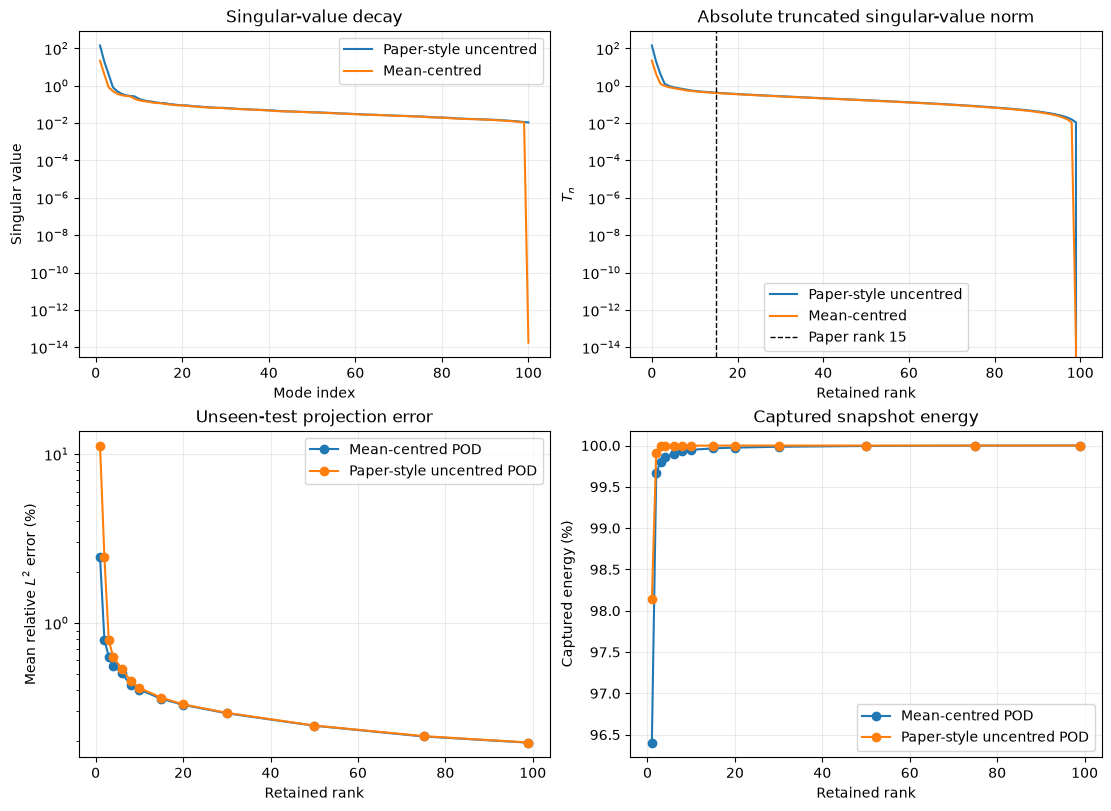

Saved tables:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/exact_paper_method_reproduction/centred_uncentred_tail_diagnostics.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/exact_paper_method_reproduction/centred_uncentred_projection_errors.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/exact_paper_method_reproduction/relative_tail_rank_criteria.csv

Saved figures:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/exact_paper_method_reproduction/centred_uncentred_pod_diagnostics.pdf
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/exact_paper_method_reproduction/centred_uncentred_pod_diagnostics.png

Stage 2 artifacts saved successfully: True


In [8]:
TAIL_TABLE_PATH = (
    TABLE_DIRECTORY
    / "centred_uncentred_tail_diagnostics.csv"
)

PROJECTION_TABLE_PATH = (
    TABLE_DIRECTORY
    / "centred_uncentred_projection_errors.csv"
)

TAIL_CRITERION_PATH = (
    TABLE_DIRECTORY
    / "relative_tail_rank_criteria.csv"
)

POD_FIGURE_PDF = (
    FIGURE_DIRECTORY
    / "centred_uncentred_pod_diagnostics.pdf"
)

POD_FIGURE_PNG = (
    FIGURE_DIRECTORY
    / "centred_uncentred_pod_diagnostics.png"
)


tail_diagnostic_table.to_csv(
    TAIL_TABLE_PATH,
    index=False,
)

projection_error_table.to_csv(
    PROJECTION_TABLE_PATH,
    index=False,
)

relative_tail_criterion_table.to_csv(
    TAIL_CRITERION_PATH,
    index=False,
)


figure, axes = plt.subplots(
    2,
    2,
    figsize=(11, 8),
    constrained_layout=True,
)


axes[0, 0].semilogy(
    np.arange(
        1,
        len(
            uncentred_singular_values
        ) + 1,
    ),
    uncentred_singular_values,
    label="Paper-style uncentred",
)

axes[0, 0].semilogy(
    np.arange(
        1,
        len(
            centred_singular_values
        ) + 1,
    ),
    centred_singular_values,
    label="Mean-centred",
)

axes[0, 0].set_title(
    "Singular-value decay"
)

axes[0, 0].set_xlabel("Mode index")
axes[0, 0].set_ylabel("Singular value")
axes[0, 0].legend()


axes[0, 1].semilogy(
    np.arange(
        len(
            uncentred_tail_norms
        )
    ),
    uncentred_tail_norms,
    label="Paper-style uncentred",
)

axes[0, 1].semilogy(
    np.arange(
        len(
            centred_tail_norms
        )
    ),
    centred_tail_norms,
    label="Mean-centred",
)

axes[0, 1].axvline(
    15,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Paper rank 15",
)

axes[0, 1].set_title(
    "Absolute truncated singular-value norm"
)

axes[0, 1].set_xlabel("Retained rank")
axes[0, 1].set_ylabel(r"$T_n$")
axes[0, 1].legend()


for formulation, group in (
    projection_error_table.groupby(
        "formulation"
    )
):
    axes[1, 0].semilogy(
        group["rank"],
        group[
            "mean_test_projection_error_percent"
        ],
        marker="o",
        label=formulation,
    )

axes[1, 0].set_title(
    "Unseen-test projection error"
)

axes[1, 0].set_xlabel("Retained rank")

axes[1, 0].set_ylabel(
    r"Mean relative $L^2$ error (%)"
)

axes[1, 0].legend()


for formulation, group in (
    tail_diagnostic_table.groupby(
        "formulation"
    )
):
    axes[1, 1].plot(
        group["rank"],
        group[
            "captured_energy_percent"
        ],
        marker="o",
        label=formulation,
    )

axes[1, 1].set_title(
    "Captured snapshot energy"
)

axes[1, 1].set_xlabel("Retained rank")
axes[1, 1].set_ylabel("Captured energy (%)")
axes[1, 1].legend()


for axis in axes.ravel():
    axis.grid(
        True,
        alpha=0.25,
    )


figure.savefig(
    POD_FIGURE_PDF,
    bbox_inches="tight",
)

figure.savefig(
    POD_FIGURE_PNG,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print("Saved tables:")

for path in [
    TAIL_TABLE_PATH,
    PROJECTION_TABLE_PATH,
    TAIL_CRITERION_PATH,
]:
    print(path)


print("\nSaved figures:")

for path in [
    POD_FIGURE_PDF,
    POD_FIGURE_PNG,
]:
    print(path)


assert all(
    path.is_file()
    for path in [
        TAIL_TABLE_PATH,
        PROJECTION_TABLE_PATH,
        TAIL_CRITERION_PATH,
        POD_FIGURE_PDF,
        POD_FIGURE_PNG,
    ]
)

print(
    "\nStage 2 artifacts saved successfully:",
    True,
)

## 2. Paper-style rank-15 neural surrogate

The architecture follows the available paper specification. Any
implementation choice not reported in the draft is stated explicitly
and tested where practical.

In [9]:
PAPER_RANK = 15
PARAMETER_DIMENSION = 1

PAPER_HIDDEN_WIDTH = (
    3
    * (
        PARAMETER_DIMENSION
        + PAPER_RANK
    )
)

PAPER_VALIDATION_COUNT = 10
PAPER_SPLIT_SEED = 20260818

PAPER_RESTART_SEEDS = [
    11,
    23,
    47,
    83,
    131,
]


paper_basis = (
    uncentred_modes[
        :,
        :PAPER_RANK,
    ]
)

paper_coefficients = (
    paper_basis.T
    @ train_snapshot_matrix
)


# Keep the domain endpoints in the neural-network
# fitting set so validation remains interpolation.
split_generator = np.random.default_rng(
    PAPER_SPLIT_SEED
)

interior_indices = np.arange(
    1,
    train_parameters.size - 1,
)

paper_validation_indices = np.sort(
    split_generator.choice(
        interior_indices,
        size=PAPER_VALIDATION_COUNT,
        replace=False,
    )
)

paper_fitting_indices = np.setdiff1d(
    np.arange(
        train_parameters.size
    ),
    paper_validation_indices,
)


paper_fitting_parameters = (
    train_parameters[
        paper_fitting_indices
    ]
)

paper_validation_parameters = (
    train_parameters[
        paper_validation_indices
    ]
)

paper_fitting_coefficients = (
    paper_coefficients[
        :,
        paper_fitting_indices,
    ].T
)

paper_validation_coefficients = (
    paper_coefficients[
        :,
        paper_validation_indices,
    ].T
)


parameter_minimum = float(
    train_parameters.min()
)

parameter_maximum = float(
    train_parameters.max()
)


def scale_parameter_values(
    parameter_values,
):
    parameter_values = np.asarray(
        parameter_values,
        dtype=float,
    )

    return (
        2.0
        * (
            parameter_values
            - parameter_minimum
        )
        / (
            parameter_maximum
            - parameter_minimum
        )
        - 1.0
    )


coefficient_training_mean = (
    paper_fitting_coefficients.mean(
        axis=0,
        keepdims=True,
    )
)

coefficient_training_scale = (
    paper_fitting_coefficients.std(
        axis=0,
        ddof=0,
        keepdims=True,
    )
)


def standardise_coefficients(
    coefficient_values,
):
    return (
        np.asarray(
            coefficient_values,
            dtype=float,
        )
        - coefficient_training_mean
    ) / coefficient_training_scale


def unstandardise_coefficients(
    standardised_values,
):
    return (
        np.asarray(
            standardised_values,
            dtype=float,
        )
        * coefficient_training_scale
        + coefficient_training_mean
    )


fitting_inputs_scaled = (
    scale_parameter_values(
        paper_fitting_parameters
    ).reshape(-1, 1)
)

validation_inputs_scaled = (
    scale_parameter_values(
        paper_validation_parameters
    ).reshape(-1, 1)
)

fitting_targets_scaled = (
    standardise_coefficients(
        paper_fitting_coefficients
    )
)

validation_targets_scaled = (
    standardise_coefficients(
        paper_validation_coefficients
    )
)


print("Paper POD rank:", PAPER_RANK)
print("Input dimension:", PARAMETER_DIMENSION)
print("Hidden width:", PAPER_HIDDEN_WIDTH)

print(
    "Neural-network fitting/validation:",
    len(paper_fitting_indices),
    len(paper_validation_indices),
)

print(
    "Fitting parameter range:",
    float(
        paper_fitting_parameters.min()
    ),
    "to",
    float(
        paper_fitting_parameters.max()
    ),
)

print(
    "Validation parameters:",
    paper_validation_parameters,
)

print(
    "Coefficient matrix:",
    paper_coefficients.shape,
)

print(
    "Scaled fitting input range:",
    float(fitting_inputs_scaled.min()),
    "to",
    float(fitting_inputs_scaled.max()),
)

print(
    "Maximum absolute scaled-target mean:",
    float(
        np.max(
            np.abs(
                fitting_targets_scaled.mean(
                    axis=0
                )
            )
        )
    ),
)


assert paper_basis.shape == (
    10000,
    PAPER_RANK,
)

assert paper_coefficients.shape == (
    PAPER_RANK,
    100,
)

assert len(paper_fitting_indices) == 90
assert len(paper_validation_indices) == 10

assert not np.intersect1d(
    paper_fitting_indices,
    paper_validation_indices,
).size

assert np.all(
    coefficient_training_scale > 0
)

assert np.isfinite(
    fitting_targets_scaled
).all()

assert np.isfinite(
    validation_targets_scaled
).all()

print(
    "\nPaper-style neural dataset "
    "construction passed:",
    True,
)

Paper POD rank: 15
Input dimension: 1
Hidden width: 48
Neural-network fitting/validation: 90 10
Fitting parameter range: 1.0 to 2.0
Validation parameters: [1.050505 1.080808 1.282828 1.313131 1.373737 1.40404  1.424242 1.515152
 1.535354 1.656566]
Coefficient matrix: (15, 100)
Scaled fitting input range: -1.0 to 1.0
Maximum absolute scaled-target mean: 4.0486132964664044e-15

Paper-style neural dataset construction passed: True


In [10]:
TORCH_DTYPE = torch.float64

PAPER_MAX_ITERATIONS = 500
PAPER_HISTORY_SIZE = 100
PAPER_LBFGS_LEARNING_RATE = 1.0


class PaperStyleNetwork(
    torch.nn.Module
):
    def __init__(
        self,
        input_dimension,
        output_dimension,
    ):
        super().__init__()

        hidden_width = (
            3
            * (
                input_dimension
                + output_dimension
            )
        )

        self.network = torch.nn.Sequential(
            torch.nn.Linear(
                input_dimension,
                hidden_width,
                dtype=TORCH_DTYPE,
            ),
            torch.nn.Tanh(),
            torch.nn.Linear(
                hidden_width,
                hidden_width,
                dtype=TORCH_DTYPE,
            ),
            torch.nn.Tanh(),
            torch.nn.Linear(
                hidden_width,
                output_dimension,
                dtype=TORCH_DTYPE,
            ),
        )

    def forward(self, inputs):
        return self.network(inputs)


fitting_input_tensor = torch.tensor(
    fitting_inputs_scaled,
    dtype=TORCH_DTYPE,
)

fitting_target_tensor = torch.tensor(
    fitting_targets_scaled,
    dtype=TORCH_DTYPE,
)

validation_input_tensor = torch.tensor(
    validation_inputs_scaled,
    dtype=TORCH_DTYPE,
)

validation_target_tensor = torch.tensor(
    validation_targets_scaled,
    dtype=TORCH_DTYPE,
)


def train_paper_style_restart(
    random_seed,
):
    torch.manual_seed(
        random_seed
    )

    model = PaperStyleNetwork(
        input_dimension=(
            PARAMETER_DIMENSION
        ),
        output_dimension=PAPER_RANK,
    )

    loss_function = (
        torch.nn.MSELoss()
    )

    optimiser = torch.optim.LBFGS(
        model.parameters(),
        lr=PAPER_LBFGS_LEARNING_RATE,
        max_iter=PAPER_MAX_ITERATIONS,
        max_eval=(
            int(
                1.25
                * PAPER_MAX_ITERATIONS
            )
        ),
        tolerance_grad=1e-12,
        tolerance_change=1e-14,
        history_size=(
            PAPER_HISTORY_SIZE
        ),
        line_search_fn="strong_wolfe",
    )

    closure_calls = 0

    def closure():
        nonlocal closure_calls

        optimiser.zero_grad()

        prediction = model(
            fitting_input_tensor
        )

        loss = loss_function(
            prediction,
            fitting_target_tensor,
        )

        loss.backward()

        closure_calls += 1

        return loss

    optimiser.step(closure)

    model.eval()

    with torch.no_grad():
        fitting_prediction = model(
            fitting_input_tensor
        )

        validation_prediction = model(
            validation_input_tensor
        )

        fitting_mse = float(
            loss_function(
                fitting_prediction,
                fitting_target_tensor,
            ).item()
        )

        validation_mse = float(
            loss_function(
                validation_prediction,
                validation_target_tensor,
            ).item()
        )

    squared_gradient_sum = 0.0

    for parameter in model.parameters():
        if parameter.grad is not None:
            squared_gradient_sum += float(
                torch.sum(
                    parameter.grad**2
                ).item()
            )

    gradient_norm = (
        squared_gradient_sum**0.5
    )

    return {
        "model": model,
        "random_seed": random_seed,
        "closure_calls": closure_calls,
        "fitting_standardised_mse":
            fitting_mse,
        "validation_standardised_mse":
            validation_mse,
        "final_gradient_norm":
            gradient_norm,
    }


def predict_standardised_coefficients(
    model,
    scaled_inputs,
):
    input_tensor = torch.tensor(
        np.asarray(
            scaled_inputs,
            dtype=float,
        ),
        dtype=TORCH_DTYPE,
    )

    model.eval()

    with torch.no_grad():
        return (
            model(input_tensor)
            .cpu()
            .numpy()
        )


print(
    "Paper-style network architecture:"
)

display(
    PaperStyleNetwork(
        PARAMETER_DIMENSION,
        PAPER_RANK,
    )
)

print(
    "\nL-BFGS maximum iterations:",
    PAPER_MAX_ITERATIONS,
)

print(
    "Number of controlled restarts:",
    len(PAPER_RESTART_SEEDS),
)

print(
    "\nPaper-style training functions defined."
)

Paper-style network architecture:


PaperStyleNetwork(
  (network): Sequential(
    (0): Linear(in_features=1, out_features=48, bias=True)
    (1): Tanh()
    (2): Linear(in_features=48, out_features=48, bias=True)
    (3): Tanh()
    (4): Linear(in_features=48, out_features=15, bias=True)
  )
)


L-BFGS maximum iterations: 500
Number of controlled restarts: 5

Paper-style training functions defined.


In [11]:
paper_restart_results = []
paper_restart_models = {}


for restart_number, random_seed in enumerate(
    PAPER_RESTART_SEEDS,
    start=1,
):
    print(
        f"Running restart "
        f"{restart_number} of "
        f"{len(PAPER_RESTART_SEEDS)} "
        f"(seed {random_seed})..."
    )

    restart_result = (
        train_paper_style_restart(
            random_seed
        )
    )

    model = restart_result["model"]

    predicted_validation_scaled = (
        predict_standardised_coefficients(
            model,
            validation_inputs_scaled,
        )
    )

    predicted_validation_coefficients = (
        unstandardise_coefficients(
            predicted_validation_scaled
        )
    )

    predicted_validation_snapshots = (
        paper_basis
        @ predicted_validation_coefficients.T
    )

    true_validation_snapshots = (
        train_snapshot_matrix[
            :,
            paper_validation_indices,
        ]
    )

    validation_field_errors = (
        relative_column_errors(
            true_validation_snapshots,
            predicted_validation_snapshots,
        )
    )


    paper_restart_models[
        random_seed
    ] = model

    paper_restart_results.append(
        {
            "restart_number":
                restart_number,
            "random_seed":
                random_seed,
            "closure_calls":
                restart_result[
                    "closure_calls"
                ],
            "fitting_standardised_mse":
                restart_result[
                    "fitting_standardised_mse"
                ],
            "validation_standardised_mse":
                restart_result[
                    "validation_standardised_mse"
                ],
            "validation_mean_field_error_percent":
                100
                * validation_field_errors.mean(),
            "validation_maximum_field_error_percent":
                100
                * validation_field_errors.max(),
            "final_gradient_norm":
                restart_result[
                    "final_gradient_norm"
                ],
        }
    )

    print(
        "  Validation standardised MSE:",
        f"{restart_result['validation_standardised_mse']:.6e}",
    )

    print(
        "  Mean validation field error:",
        f"{100 * validation_field_errors.mean():.6f}%",
    )


paper_restart_table = (
    pd.DataFrame(
        paper_restart_results
    )
    .sort_values(
        [
            "validation_standardised_mse",
            "random_seed",
        ]
    )
    .reset_index(drop=True)
)


print(
    "\nPaper-style restart comparison:"
)

display(
    paper_restart_table.style.format(
        {
            "fitting_standardised_mse":
                "{:.6e}",
            "validation_standardised_mse":
                "{:.6e}",
            "validation_mean_field_error_percent":
                "{:.6f}",
            "validation_maximum_field_error_percent":
                "{:.6f}",
            "final_gradient_norm":
                "{:.6e}",
        }
    )
)


selected_paper_seed = int(
    paper_restart_table.iloc[0][
        "random_seed"
    ]
)

selected_paper_model = (
    paper_restart_models[
        selected_paper_seed
    ]
)


print(
    "\nSelected restart seed:",
    selected_paper_seed,
)

print(
    "Selection criterion: minimum "
    "validation standardised coefficient MSE"
)


assert len(paper_restart_table) == 5

assert paper_restart_table[
    "random_seed"
].is_unique

assert np.isfinite(
    paper_restart_table.select_dtypes(
        include=[np.number]
    )
).all().all()

print(
    "\nControlled-restart training passed:",
    True,
)

Running restart 1 of 5 (seed 11)...
  Validation standardised MSE: 1.534525e+00
  Mean validation field error: 1.342903%
Running restart 2 of 5 (seed 23)...
  Validation standardised MSE: 1.443216e+00
  Mean validation field error: 1.605735%
Running restart 3 of 5 (seed 47)...
  Validation standardised MSE: 1.275324e+00
  Mean validation field error: 1.124201%
Running restart 4 of 5 (seed 83)...
  Validation standardised MSE: 1.509098e+00
  Mean validation field error: 1.402517%
Running restart 5 of 5 (seed 131)...
  Validation standardised MSE: 1.389338e+00
  Mean validation field error: 1.517322%

Paper-style restart comparison:


,restart_number,random_seed,closure_calls,fitting_standardised_mse,validation_standardised_mse,validation_mean_field_error_percent,validation_maximum_field_error_percent,final_gradient_norm
0,3,47,502,5.943558e-01,1.275324e+00,1.124201,2.115380,5.282961e-02
1,5,131,507,5.953169e-01,1.389338e+00,1.517322,2.568728,2.170461e-02
2,2,23,506,5.731463e-01,1.443216e+00,1.605735,2.413985,3.012110e-02
3,4,83,504,5.633028e-01,1.509098e+00,1.402517,2.504927,3.271427e-02
4,1,11,504,5.679276e-01,1.534525e+00,1.342903,2.390616,2.358092e-02



Selected restart seed: 47
Selection criterion: minimum validation standardised coefficient MSE

Controlled-restart training passed: True


In [12]:
test_inputs_scaled = (
    scale_parameter_values(
        test_parameters
    ).reshape(-1, 1)
)

predicted_test_coefficients = (
    unstandardise_coefficients(
        predict_standardised_coefficients(
            selected_paper_model,
            test_inputs_scaled,
        )
    )
)

paper_predicted_test_snapshots = (
    paper_basis
    @ predicted_test_coefficients.T
)


paper_projected_test_coefficients = (
    paper_basis.T
    @ test_snapshot_matrix
)

paper_projected_test_snapshots = (
    paper_basis
    @ paper_projected_test_coefficients
)


paper_test_errors = (
    relative_column_errors(
        test_snapshot_matrix,
        paper_predicted_test_snapshots,
    )
)

paper_projection_test_errors = (
    relative_column_errors(
        test_snapshot_matrix,
        paper_projected_test_snapshots,
    )
)


cell_area = (
    grid_spacing_x
    * grid_spacing_z
)

true_test_integrals = (
    test_snapshot_matrix.sum(
        axis=0
    )
    * cell_area
)

predicted_test_integrals = (
    paper_predicted_test_snapshots.sum(
        axis=0
    )
    * cell_area
)

integral_errors_percent = (
    100
    * (
        predicted_test_integrals
        - true_test_integrals
    )
    / true_test_integrals
)


paper_test_case_table = pd.DataFrame(
    {
        "size_ratio":
            test_parameters,
        "projection_error_percent":
            100
            * paper_projection_test_errors,
        "paper_style_nn_error_percent":
            100 * paper_test_errors,
        "excess_above_projection_percent":
            100
            * (
                paper_test_errors
                - paper_projection_test_errors
            ),
        "integral_error_percent":
            integral_errors_percent,
    }
)


print(
    "Paper-style rank-15 external test results:"
)

display(
    paper_test_case_table.style.format(
        {
            column: "{:.6f}"
            for column in (
                paper_test_case_table.columns
            )
        }
    )
)


paper_external_summary = pd.DataFrame(
    [
        {
            "model":
                "Rank-15 paper-style "
                "uncentred NN",
            "rank": PAPER_RANK,
            "mean_test_error_percent":
                100
                * paper_test_errors.mean(),
            "median_test_error_percent":
                100
                * np.median(
                    paper_test_errors
                ),
            "maximum_test_error_percent":
                100
                * paper_test_errors.max(),
            "mean_projection_error_percent":
                100
                * paper_projection_test_errors.mean(),
            "mean_absolute_integral_error_percent":
                np.mean(
                    np.abs(
                        integral_errors_percent
                    )
                ),
            "minimum_prediction":
                paper_predicted_test_snapshots.min(),
            "maximum_prediction":
                paper_predicted_test_snapshots.max(),
        }
    ]
)


print("\nPaper-style external summary:")

display(
    paper_external_summary.style.format(
        {
            "mean_test_error_percent":
                "{:.6f}",
            "median_test_error_percent":
                "{:.6f}",
            "maximum_test_error_percent":
                "{:.6f}",
            "mean_projection_error_percent":
                "{:.6f}",
            "mean_absolute_integral_error_percent":
                "{:.6f}",
            "minimum_prediction":
                "{:.6e}",
            "maximum_prediction":
                "{:.6f}",
        }
    )
)


print(
    "\nExisting baseline comparison:"
)

display(
    baseline_summary[
        [
            "model",
            "rank",
            "mean_test_error_percent",
            "median_test_error_percent",
            "maximum_test_error_percent",
        ]
    ].style.format(
        {
            "mean_test_error_percent":
                "{:.6f}",
            "median_test_error_percent":
                "{:.6f}",
            "maximum_test_error_percent":
                "{:.6f}",
        }
    )
)


assert np.all(
    paper_test_errors
    + 1e-12
    >= paper_projection_test_errors
)

assert np.isfinite(
    paper_test_case_table.select_dtypes(
        include=[np.number]
    )
).all().all()

print(
    "\nExternal paper-style evaluation passed:",
    True,
)

Paper-style rank-15 external test results:


,size_ratio,projection_error_percent,paper_style_nn_error_percent,excess_above_projection_percent,integral_error_percent
0,1.062500,0.497520,1.701873,1.204353,0.576694
1,1.125000,0.494456,1.613168,1.118712,0.425045
2,1.250000,0.406535,0.913209,0.506673,-0.586979
3,1.312500,0.426096,0.726886,0.300789,-0.081849
4,1.375000,0.330373,0.807745,0.477371,-0.022327
5,1.500000,0.290388,0.971122,0.680734,-0.284982
6,1.562500,0.307869,0.670638,0.362769,-0.006268
7,1.625000,0.322787,0.855100,0.532312,0.080025
8,1.750000,0.282240,0.631483,0.349243,-0.284202
9,1.875000,0.253417,0.640894,0.387476,-0.049318



Paper-style external summary:


,model,rank,mean_test_error_percent,median_test_error_percent,maximum_test_error_percent,mean_projection_error_percent,mean_absolute_integral_error_percent,minimum_prediction,maximum_prediction
0,Rank-15 paper-style uncentred NN,15,0.953212,0.831422,1.701873,0.361168,0.239769,-5.749926e-06,0.540019



Existing baseline comparison:


,model,rank,mean_test_error_percent,median_test_error_percent,maximum_test_error_percent
0,rank_4_rom,4,0.927337,0.815996,1.527620
1,rank_6_rom,6,0.839298,0.805800,1.304164



External paper-style evaluation passed: True


## 3. Coefficient-scaling sensitivity

Because the draft does not specify output scaling, raw coefficients
are treated as the primary paper-faithful interpretation and per-mode
standardisation is evaluated as a conditioning sensitivity.

In [13]:
raw_fitting_target_tensor = torch.tensor(
    paper_fitting_coefficients,
    dtype=TORCH_DTYPE,
)

raw_validation_target_tensor = torch.tensor(
    paper_validation_coefficients,
    dtype=TORCH_DTYPE,
)


def train_raw_coefficient_restart(
    random_seed,
):
    """
    Train the paper architecture directly on raw POD
    coefficients, as written in the draft equations.
    """
    torch.manual_seed(
        random_seed
    )

    model = PaperStyleNetwork(
        input_dimension=(
            PARAMETER_DIMENSION
        ),
        output_dimension=PAPER_RANK,
    )

    loss_function = (
        torch.nn.MSELoss()
    )

    optimiser = torch.optim.LBFGS(
        model.parameters(),
        lr=PAPER_LBFGS_LEARNING_RATE,
        max_iter=PAPER_MAX_ITERATIONS,
        max_eval=(
            int(
                1.25
                * PAPER_MAX_ITERATIONS
            )
        ),
        tolerance_grad=1e-12,
        tolerance_change=1e-14,
        history_size=(
            PAPER_HISTORY_SIZE
        ),
        line_search_fn="strong_wolfe",
    )

    closure_calls = 0

    def closure():
        nonlocal closure_calls

        optimiser.zero_grad()

        prediction = model(
            fitting_input_tensor
        )

        loss = loss_function(
            prediction,
            raw_fitting_target_tensor,
        )

        loss.backward()

        closure_calls += 1

        return loss

    optimiser.step(closure)

    model.eval()

    with torch.no_grad():
        fitting_prediction = model(
            fitting_input_tensor
        )

        validation_prediction = model(
            validation_input_tensor
        )

        fitting_mse = float(
            loss_function(
                fitting_prediction,
                raw_fitting_target_tensor,
            ).item()
        )

        validation_mse = float(
            loss_function(
                validation_prediction,
                raw_validation_target_tensor,
            ).item()
        )

    squared_gradient_sum = 0.0

    for parameter in model.parameters():
        if parameter.grad is not None:
            squared_gradient_sum += float(
                torch.sum(
                    parameter.grad**2
                ).item()
            )

    return {
        "model": model,
        "random_seed": random_seed,
        "closure_calls": closure_calls,
        "fitting_raw_coefficient_mse":
            fitting_mse,
        "validation_raw_coefficient_mse":
            validation_mse,
        "final_gradient_norm":
            squared_gradient_sum**0.5,
    }


def predict_raw_coefficients(
    model,
    scaled_inputs,
):
    input_tensor = torch.tensor(
        np.asarray(
            scaled_inputs,
            dtype=float,
        ),
        dtype=TORCH_DTYPE,
    )

    model.eval()

    with torch.no_grad():
        return (
            model(input_tensor)
            .cpu()
            .numpy()
        )


print(
    "Raw-coefficient paper-style "
    "training functions defined."
)

print(
    "This is the primary architecture-faithful "
    "interpretation because the draft does not "
    "state that coefficients were standardised."
)

Raw-coefficient paper-style training functions defined.
This is the primary architecture-faithful interpretation because the draft does not state that coefficients were standardised.


In [14]:
raw_restart_records = []
raw_restart_models = {}


for restart_number, random_seed in enumerate(
    PAPER_RESTART_SEEDS,
    start=1,
):
    print(
        f"Running raw-coefficient restart "
        f"{restart_number} of "
        f"{len(PAPER_RESTART_SEEDS)} "
        f"(seed {random_seed})..."
    )

    restart_result = (
        train_raw_coefficient_restart(
            random_seed
        )
    )

    model = restart_result["model"]

    predicted_validation_coefficients_raw = (
        predict_raw_coefficients(
            model,
            validation_inputs_scaled,
        )
    )

    predicted_validation_snapshots_raw = (
        paper_basis
        @ predicted_validation_coefficients_raw.T
    )

    true_validation_snapshots = (
        train_snapshot_matrix[
            :,
            paper_validation_indices,
        ]
    )

    validation_field_errors_raw = (
        relative_column_errors(
            true_validation_snapshots,
            predicted_validation_snapshots_raw,
        )
    )

    true_validation_integrals = (
        true_validation_snapshots.sum(
            axis=0
        )
        * cell_area
    )

    predicted_validation_integrals = (
        predicted_validation_snapshots_raw.sum(
            axis=0
        )
        * cell_area
    )

    validation_integral_errors_raw = (
        100
        * (
            predicted_validation_integrals
            - true_validation_integrals
        )
        / true_validation_integrals
    )


    raw_restart_models[
        random_seed
    ] = model

    raw_restart_records.append(
        {
            "restart_number":
                restart_number,
            "random_seed":
                random_seed,
            "closure_calls":
                restart_result[
                    "closure_calls"
                ],
            "fitting_raw_coefficient_mse":
                restart_result[
                    "fitting_raw_coefficient_mse"
                ],
            "validation_raw_coefficient_mse":
                restart_result[
                    "validation_raw_coefficient_mse"
                ],
            "validation_mean_field_error_percent":
                100
                * validation_field_errors_raw.mean(),
            "validation_maximum_field_error_percent":
                100
                * validation_field_errors_raw.max(),
            "validation_mean_absolute_integral_error_percent":
                np.mean(
                    np.abs(
                        validation_integral_errors_raw
                    )
                ),
            "final_gradient_norm":
                restart_result[
                    "final_gradient_norm"
                ],
        }
    )

    print(
        "  Validation raw coefficient MSE:",
        f"{restart_result['validation_raw_coefficient_mse']:.6e}",
    )

    print(
        "  Mean validation field error:",
        f"{100 * validation_field_errors_raw.mean():.6f}%",
    )


raw_restart_table = (
    pd.DataFrame(
        raw_restart_records
    )
    .sort_values(
        [
            "validation_raw_coefficient_mse",
            "random_seed",
        ]
    )
    .reset_index(drop=True)
)


print(
    "\nRaw-coefficient restart comparison:"
)

display(
    raw_restart_table.style.format(
        {
            "fitting_raw_coefficient_mse":
                "{:.6e}",
            "validation_raw_coefficient_mse":
                "{:.6e}",
            "validation_mean_field_error_percent":
                "{:.6f}",
            "validation_maximum_field_error_percent":
                "{:.6f}",
            "validation_mean_absolute_integral_error_percent":
                "{:.6f}",
            "final_gradient_norm":
                "{:.6e}",
        }
    )
)


selected_raw_seed = int(
    raw_restart_table.iloc[0][
        "random_seed"
    ]
)

selected_raw_model = (
    raw_restart_models[
        selected_raw_seed
    ]
)


print(
    "\nSelected raw-coefficient seed:",
    selected_raw_seed,
)

print(
    "Selection criterion: minimum validation "
    "raw-coefficient MSE, matching the draft's "
    "stated optimisation objective."
)


assert len(raw_restart_table) == 5

assert raw_restart_table[
    "random_seed"
].is_unique

assert np.isfinite(
    raw_restart_table.select_dtypes(
        include=[np.number]
    )
).all().all()

print(
    "\nRaw-coefficient restart study passed:",
    True,
)

Running raw-coefficient restart 1 of 5 (seed 11)...
  Validation raw coefficient MSE: 1.389679e-03
  Mean validation field error: 1.032952%
Running raw-coefficient restart 2 of 5 (seed 23)...
  Validation raw coefficient MSE: 1.399586e-03
  Mean validation field error: 1.035914%
Running raw-coefficient restart 3 of 5 (seed 47)...
  Validation raw coefficient MSE: 1.401407e-03
  Mean validation field error: 1.036444%
Running raw-coefficient restart 4 of 5 (seed 83)...
  Validation raw coefficient MSE: 1.399516e-03
  Mean validation field error: 1.033909%
Running raw-coefficient restart 5 of 5 (seed 131)...
  Validation raw coefficient MSE: 1.394265e-03
  Mean validation field error: 1.030052%

Raw-coefficient restart comparison:


,restart_number,random_seed,closure_calls,fitting_raw_coefficient_mse,validation_raw_coefficient_mse,validation_mean_field_error_percent,validation_maximum_field_error_percent,validation_mean_absolute_integral_error_percent,final_gradient_norm
0,1,11,522,8.389825e-04,1.389679e-03,1.032952,1.961890,0.010900,2.379710e-04
1,5,131,510,8.477982e-04,1.394265e-03,1.030052,1.999548,0.026329,1.358276e-03
2,4,83,522,8.568115e-04,1.399516e-03,1.033909,1.987907,0.034757,3.241431e-04
3,2,23,511,8.432578e-04,1.399586e-03,1.035914,1.982572,0.021376,2.393969e-04
4,3,47,510,8.484849e-04,1.401407e-03,1.036444,1.979072,0.011411,8.302477e-05



Selected raw-coefficient seed: 11
Selection criterion: minimum validation raw-coefficient MSE, matching the draft's stated optimisation objective.

Raw-coefficient restart study passed: True


In [15]:
raw_predicted_test_coefficients = (
    predict_raw_coefficients(
        selected_raw_model,
        test_inputs_scaled,
    )
)

raw_predicted_test_snapshots = (
    paper_basis
    @ raw_predicted_test_coefficients.T
)

raw_paper_test_errors = (
    relative_column_errors(
        test_snapshot_matrix,
        raw_predicted_test_snapshots,
    )
)


raw_predicted_test_integrals = (
    raw_predicted_test_snapshots.sum(
        axis=0
    )
    * cell_area
)

raw_integral_errors_percent = (
    100
    * (
        raw_predicted_test_integrals
        - true_test_integrals
    )
    / true_test_integrals
)


raw_test_case_table = pd.DataFrame(
    {
        "size_ratio":
            test_parameters,
        "projection_error_percent":
            100
            * paper_projection_test_errors,
        "raw_coefficient_nn_error_percent":
            100
            * raw_paper_test_errors,
        "standardised_coefficient_nn_error_percent":
            100
            * paper_test_errors,
        "raw_integral_error_percent":
            raw_integral_errors_percent,
        "standardised_integral_error_percent":
            integral_errors_percent,
    }
)


print(
    "External coefficient-scaling comparison:"
)

display(
    raw_test_case_table.style.format(
        {
            column: "{:.6f}"
            for column in (
                raw_test_case_table.columns
            )
        }
    )
)


scaling_summary = pd.DataFrame(
    [
        {
            "protocol":
                "Raw coefficients "
                "(draft-faithful primary)",
            "selected_seed":
                selected_raw_seed,
            "mean_test_error_percent":
                100
                * raw_paper_test_errors.mean(),
            "median_test_error_percent":
                100
                * np.median(
                    raw_paper_test_errors
                ),
            "maximum_test_error_percent":
                100
                * raw_paper_test_errors.max(),
            "mean_absolute_integral_error_percent":
                np.mean(
                    np.abs(
                        raw_integral_errors_percent
                    )
                ),
            "minimum_prediction":
                raw_predicted_test_snapshots.min(),
            "maximum_prediction":
                raw_predicted_test_snapshots.max(),
        },
        {
            "protocol":
                "Per-mode standardised coefficients "
                "(conditioning sensitivity)",
            "selected_seed":
                selected_paper_seed,
            "mean_test_error_percent":
                100
                * paper_test_errors.mean(),
            "median_test_error_percent":
                100
                * np.median(
                    paper_test_errors
                ),
            "maximum_test_error_percent":
                100
                * paper_test_errors.max(),
            "mean_absolute_integral_error_percent":
                np.mean(
                    np.abs(
                        integral_errors_percent
                    )
                ),
            "minimum_prediction":
                paper_predicted_test_snapshots.min(),
            "maximum_prediction":
                paper_predicted_test_snapshots.max(),
        },
    ]
)


print(
    "\nExternal scaling summary:"
)

display(
    scaling_summary.style.format(
        {
            "mean_test_error_percent":
                "{:.6f}",
            "median_test_error_percent":
                "{:.6f}",
            "maximum_test_error_percent":
                "{:.6f}",
            "mean_absolute_integral_error_percent":
                "{:.6f}",
            "minimum_prediction":
                "{:.6e}",
            "maximum_prediction":
                "{:.6f}",
        }
    )
)


raw_mode_error_percent = (
    100
    * np.linalg.norm(
        raw_predicted_test_coefficients.T
        - paper_projected_test_coefficients,
        axis=1,
    )
    / np.maximum(
        np.linalg.norm(
            paper_projected_test_coefficients,
            axis=1,
        ),
        np.finfo(float).tiny,
    )
)

standardised_mode_error_percent = (
    100
    * np.linalg.norm(
        predicted_test_coefficients.T
        - paper_projected_test_coefficients,
        axis=1,
    )
    / np.maximum(
        np.linalg.norm(
            paper_projected_test_coefficients,
            axis=1,
        ),
        np.finfo(float).tiny,
    )
)


mode_scaling_comparison = pd.DataFrame(
    {
        "mode":
            np.arange(
                1,
                PAPER_RANK + 1,
            ),
        "raw_coefficient_error_percent":
            raw_mode_error_percent,
        "standardised_coefficient_error_percent":
            standardised_mode_error_percent,
    }
)


print(
    "\nExternal coefficient errors by mode:"
)

display(
    mode_scaling_comparison.style.format(
        {
            "raw_coefficient_error_percent":
                "{:.6f}",
            "standardised_coefficient_error_percent":
                "{:.6f}",
        }
    )
)


assert np.all(
    raw_paper_test_errors
    + 1e-12
    >= paper_projection_test_errors
)

assert np.isfinite(
    scaling_summary.select_dtypes(
        include=[np.number]
    )
).all().all()

print(
    "\nExternal scaling comparison passed:",
    True,
)

External coefficient-scaling comparison:


,size_ratio,projection_error_percent,raw_coefficient_nn_error_percent,standardised_coefficient_nn_error_percent,raw_integral_error_percent,standardised_integral_error_percent
0,1.062500,0.497520,1.438286,1.701873,-0.021447,0.576694
1,1.125000,0.494456,1.182451,1.613168,0.029592,0.425045
2,1.250000,0.406535,0.930568,0.913209,-0.017483,-0.586979
3,1.312500,0.426096,0.709451,0.726886,-0.012832,-0.081849
4,1.375000,0.330373,0.980826,0.807745,0.012675,-0.022327
5,1.500000,0.290388,1.092884,0.971122,-0.000204,-0.284982
6,1.562500,0.307869,0.594951,0.670638,-0.001005,-0.006268
7,1.625000,0.322787,0.710570,0.855100,-0.002078,0.080025
8,1.750000,0.282240,0.448947,0.631483,0.004210,-0.284202
9,1.875000,0.253417,0.477956,0.640894,0.005418,-0.049318



External scaling summary:


,protocol,selected_seed,mean_test_error_percent,median_test_error_percent,maximum_test_error_percent,mean_absolute_integral_error_percent,minimum_prediction,maximum_prediction
0,Raw coefficients (draft-faithful primary),11,0.856689,0.820569,1.438286,0.010694,-3.015306e-06,0.538012
1,Per-mode standardised coefficients (conditioning sensitivity),47,0.953212,0.831422,1.701873,0.239769,-5.749926e-06,0.540019



External coefficient errors by mode:


,mode,raw_coefficient_error_percent,standardised_coefficient_error_percent
0,1,0.227800,0.317017
1,2,2.588677,3.469899
2,3,15.160669,16.508389
3,4,52.717848,58.852979
4,5,83.517669,80.338449
5,6,103.422482,116.193011
6,7,107.781709,111.826510
7,8,101.116885,95.455795
8,9,110.513070,124.441999
9,10,100.811987,100.791188



External scaling comparison passed: True


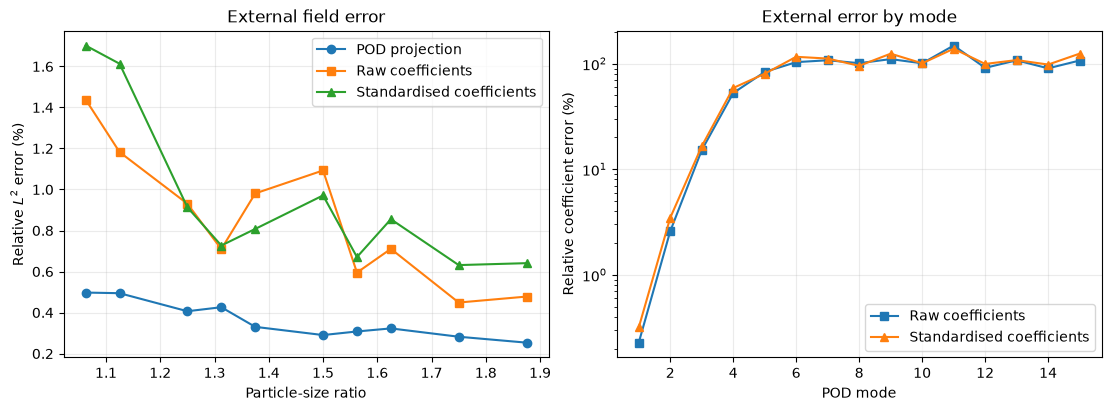

Saved scaling tables:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/exact_paper_method_reproduction/raw_coefficient_restart_comparison.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/exact_paper_method_reproduction/coefficient_scaling_test_cases.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/exact_paper_method_reproduction/coefficient_scaling_summary.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/exact_paper_method_reproduction/coefficient_scaling_mode_errors.csv

Saved scaling figures:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/exact_paper_method_reproduction/coefficient_scaling_sensitivity.pdf
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/exact_paper_method_reproduction/coefficient_scaling_sensitivity.png

Coefficient-scaling sensitivity artifacts saved: True


In [16]:
RAW_RESTART_TABLE_PATH = (
    TABLE_DIRECTORY
    / "raw_coefficient_restart_comparison.csv"
)

SCALING_CASE_TABLE_PATH = (
    TABLE_DIRECTORY
    / "coefficient_scaling_test_cases.csv"
)

SCALING_SUMMARY_PATH = (
    TABLE_DIRECTORY
    / "coefficient_scaling_summary.csv"
)

MODE_SCALING_PATH = (
    TABLE_DIRECTORY
    / "coefficient_scaling_mode_errors.csv"
)

SCALING_FIGURE_PDF = (
    FIGURE_DIRECTORY
    / "coefficient_scaling_sensitivity.pdf"
)

SCALING_FIGURE_PNG = (
    FIGURE_DIRECTORY
    / "coefficient_scaling_sensitivity.png"
)


raw_restart_table.to_csv(
    RAW_RESTART_TABLE_PATH,
    index=False,
)

raw_test_case_table.to_csv(
    SCALING_CASE_TABLE_PATH,
    index=False,
)

scaling_summary.to_csv(
    SCALING_SUMMARY_PATH,
    index=False,
)

mode_scaling_comparison.to_csv(
    MODE_SCALING_PATH,
    index=False,
)


figure, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4),
    constrained_layout=True,
)


axes[0].plot(
    test_parameters,
    100 * paper_projection_test_errors,
    marker="o",
    label="POD projection",
)

axes[0].plot(
    test_parameters,
    100 * raw_paper_test_errors,
    marker="s",
    label="Raw coefficients",
)

axes[0].plot(
    test_parameters,
    100 * paper_test_errors,
    marker="^",
    label="Standardised coefficients",
)

axes[0].set_xlabel("Particle-size ratio")

axes[0].set_ylabel(
    r"Relative $L^2$ error (%)"
)

axes[0].set_title(
    "External field error"
)

axes[0].legend()
axes[0].grid(True, alpha=0.25)


axes[1].semilogy(
    mode_scaling_comparison["mode"],
    mode_scaling_comparison[
        "raw_coefficient_error_percent"
    ],
    marker="s",
    label="Raw coefficients",
)

axes[1].semilogy(
    mode_scaling_comparison["mode"],
    mode_scaling_comparison[
        "standardised_coefficient_error_percent"
    ],
    marker="^",
    label="Standardised coefficients",
)

axes[1].set_xlabel("POD mode")

axes[1].set_ylabel(
    "Relative coefficient error (%)"
)

axes[1].set_title(
    "External error by mode"
)

axes[1].legend()
axes[1].grid(True, alpha=0.25)


figure.savefig(
    SCALING_FIGURE_PDF,
    bbox_inches="tight",
)

figure.savefig(
    SCALING_FIGURE_PNG,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print("Saved scaling tables:")

for path in [
    RAW_RESTART_TABLE_PATH,
    SCALING_CASE_TABLE_PATH,
    SCALING_SUMMARY_PATH,
    MODE_SCALING_PATH,
]:
    print(path)


print("\nSaved scaling figures:")

for path in [
    SCALING_FIGURE_PDF,
    SCALING_FIGURE_PNG,
]:
    print(path)


assert all(
    path.is_file()
    for path in [
        RAW_RESTART_TABLE_PATH,
        SCALING_CASE_TABLE_PATH,
        SCALING_SUMMARY_PATH,
        MODE_SCALING_PATH,
        SCALING_FIGURE_PDF,
        SCALING_FIGURE_PNG,
    ]
)

print(
    "\nCoefficient-scaling sensitivity "
    "artifacts saved:",
    True,
)

## 4. Rank and coefficient-training-size study

A fixed global POD basis is used so that this experiment isolates the
effect of coefficient-learning rank and neural-network training-set
size.

In [17]:
SWEEP_RANKS = np.array(
    [
        1,
        2,
        3,
        4,
        6,
        10,
        15,
        20,
    ],
    dtype=int,
)

SWEEP_TRAINING_COUNTS = [
    10,
    20,
    90,
]

SWEEP_RESTART_SEEDS = [
    11,
    47,
    131,
]


def farthest_point_order(
    candidate_indices,
    parameter_values,
):
    """
    Construct a deterministic nested ordering that
    progressively fills the one-dimensional parameter
    interval.
    """
    candidate_indices = np.asarray(
        candidate_indices,
        dtype=int,
    )

    candidate_parameters = (
        parameter_values[
            candidate_indices
        ]
    )

    first_index = int(
        candidate_indices[
            np.argmin(
                candidate_parameters
            )
        ]
    )

    last_index = int(
        candidate_indices[
            np.argmax(
                candidate_parameters
            )
        ]
    )

    selected = [
        first_index,
        last_index,
    ]

    remaining = set(
        candidate_indices.tolist()
    )

    remaining.remove(first_index)
    remaining.remove(last_index)

    while remaining:
        remaining_array = np.array(
            sorted(remaining),
            dtype=int,
        )

        remaining_parameters = (
            parameter_values[
                remaining_array
            ]
        )

        selected_parameters = (
            parameter_values[
                np.array(
                    selected,
                    dtype=int,
                )
            ]
        )

        minimum_distances = np.min(
            np.abs(
                remaining_parameters[:, None]
                - selected_parameters[None, :]
            ),
            axis=1,
        )

        maximum_distance = (
            minimum_distances.max()
        )

        tied_positions = np.flatnonzero(
            np.isclose(
                minimum_distances,
                maximum_distance,
                rtol=0.0,
                atol=1e-14,
            )
        )

        next_index = int(
            remaining_array[
                tied_positions[0]
            ]
        )

        selected.append(next_index)
        remaining.remove(next_index)

    return np.array(
        selected,
        dtype=int,
    )


nested_selection_order = (
    farthest_point_order(
        paper_fitting_indices,
        train_parameters,
    )
)


sweep_fitting_indices = {
    count: np.sort(
        nested_selection_order[
            :count
        ]
    )
    for count in (
        SWEEP_TRAINING_COUNTS
    )
}


subset_records = []

for count, indices in (
    sweep_fitting_indices.items()
):
    selected_parameters = (
        train_parameters[
            indices
        ]
    )

    sorted_parameters = np.sort(
        selected_parameters
    )

    gaps = np.diff(
        sorted_parameters
    )

    subset_records.append(
        {
            "training_count": count,
            "parameter_minimum":
                selected_parameters.min(),
            "parameter_maximum":
                selected_parameters.max(),
            "minimum_parameter_gap":
                gaps.min(),
            "maximum_parameter_gap":
                gaps.max(),
            "mean_parameter_gap":
                gaps.mean(),
        }
    )


training_subset_summary = pd.DataFrame(
    subset_records
)


print("Rank candidates:", SWEEP_RANKS)

print(
    "Training counts:",
    SWEEP_TRAINING_COUNTS,
)

print(
    "Restarts per configuration:",
    len(SWEEP_RESTART_SEEDS),
)

print(
    "Total neural fits:",
    len(SWEEP_RANKS)
    * len(SWEEP_TRAINING_COUNTS)
    * len(SWEEP_RESTART_SEEDS),
)

print(
    "\nFixed validation parameters:"
)

print(paper_validation_parameters)

print(
    "\nNested training-subset summary:"
)

display(
    training_subset_summary.style.format(
        {
            "parameter_minimum":
                "{:.6f}",
            "parameter_maximum":
                "{:.6f}",
            "minimum_parameter_gap":
                "{:.6f}",
            "maximum_parameter_gap":
                "{:.6f}",
            "mean_parameter_gap":
                "{:.6f}",
        }
    )
)


assert set(
    sweep_fitting_indices[10]
).issubset(
    set(
        sweep_fitting_indices[20]
    )
)

assert set(
    sweep_fitting_indices[20]
).issubset(
    set(
        sweep_fitting_indices[90]
    )
)

assert np.array_equal(
    sweep_fitting_indices[90],
    np.sort(
        paper_fitting_indices
    ),
)

assert 0 in sweep_fitting_indices[10]
assert 99 in sweep_fitting_indices[10]

print(
    "\nNested training-set design passed:",
    True,
)

Rank candidates: [ 1  2  3  4  6 10 15 20]
Training counts: [10, 20, 90]
Restarts per configuration: 3
Total neural fits: 72

Fixed validation parameters:
[1.050505 1.080808 1.282828 1.313131 1.373737 1.40404  1.424242 1.515152
 1.535354 1.656566]

Nested training-subset summary:


,training_count,parameter_minimum,parameter_maximum,minimum_parameter_gap,maximum_parameter_gap,mean_parameter_gap
0,10,1.000000,2.000000,0.060606,0.131313,0.111111
1,20,1.000000,2.000000,0.030303,0.070707,0.052632
2,90,1.000000,2.000000,0.010101,0.020202,0.011236



Nested training-set design passed: True


In [18]:
uncentred_training_coefficients_full = (
    uncentred_modes.T
    @ train_snapshot_matrix
)


def train_rank_count_restart(
    rank,
    fitting_indices,
    random_seed,
):
    basis = (
        uncentred_modes[
            :,
            :rank,
        ]
    )

    fitting_parameters_local = (
        train_parameters[
            fitting_indices
        ]
    )

    fitting_coefficients_local = (
        uncentred_training_coefficients_full[
            :rank,
            fitting_indices,
        ].T
    )

    validation_coefficients_local = (
        uncentred_training_coefficients_full[
            :rank,
            paper_validation_indices,
        ].T
    )


    fitting_inputs_local = torch.tensor(
        scale_parameter_values(
            fitting_parameters_local
        ).reshape(-1, 1),
        dtype=TORCH_DTYPE,
    )

    fitting_targets_local = torch.tensor(
        fitting_coefficients_local,
        dtype=TORCH_DTYPE,
    )

    validation_inputs_local = (
        validation_input_tensor
    )

    validation_targets_local = torch.tensor(
        validation_coefficients_local,
        dtype=TORCH_DTYPE,
    )


    torch.manual_seed(
        random_seed
    )

    model = PaperStyleNetwork(
        input_dimension=(
            PARAMETER_DIMENSION
        ),
        output_dimension=rank,
    )

    loss_function = (
        torch.nn.MSELoss()
    )

    optimiser = torch.optim.LBFGS(
        model.parameters(),
        lr=PAPER_LBFGS_LEARNING_RATE,
        max_iter=PAPER_MAX_ITERATIONS,
        max_eval=(
            int(
                1.25
                * PAPER_MAX_ITERATIONS
            )
        ),
        tolerance_grad=1e-12,
        tolerance_change=1e-14,
        history_size=(
            PAPER_HISTORY_SIZE
        ),
        line_search_fn="strong_wolfe",
    )

    closure_calls = 0

    def closure():
        nonlocal closure_calls

        optimiser.zero_grad()

        prediction = model(
            fitting_inputs_local
        )

        loss = loss_function(
            prediction,
            fitting_targets_local,
        )

        loss.backward()

        closure_calls += 1

        return loss

    optimiser.step(closure)

    model.eval()

    with torch.no_grad():
        fitting_prediction = model(
            fitting_inputs_local
        )

        validation_prediction = model(
            validation_inputs_local
        )

        fitting_mse = float(
            loss_function(
                fitting_prediction,
                fitting_targets_local,
            ).item()
        )

        validation_mse = float(
            loss_function(
                validation_prediction,
                validation_targets_local,
            ).item()
        )

        validation_coefficients_prediction = (
            validation_prediction
            .cpu()
            .numpy()
        )


    validation_snapshot_prediction = (
        basis
        @ validation_coefficients_prediction.T
    )

    validation_truth = (
        train_snapshot_matrix[
            :,
            paper_validation_indices,
        ]
    )

    validation_field_errors = (
        relative_column_errors(
            validation_truth,
            validation_snapshot_prediction,
        )
    )


    return {
        "model": model,
        "rank": rank,
        "training_count":
            len(fitting_indices),
        "random_seed":
            random_seed,
        "closure_calls":
            closure_calls,
        "fitting_raw_coefficient_mse":
            fitting_mse,
        "validation_raw_coefficient_mse":
            validation_mse,
        "validation_mean_field_error_percent":
            100
            * validation_field_errors.mean(),
        "validation_maximum_field_error_percent":
            100
            * validation_field_errors.max(),
    }


print(
    "Generic rank/training-count trainer defined."
)

print(
    "The fixed global POD basis isolates "
    "coefficient-learning error from changes "
    "in the POD space."
)

Generic rank/training-count trainer defined.
The fixed global POD basis isolates coefficient-learning error from changes in the POD space.


In [19]:
import time


sweep_start_time = (
    time.perf_counter()
)

sweep_restart_records = []
sweep_selected_records = []
sweep_selected_models = {}


total_configurations = (
    len(SWEEP_TRAINING_COUNTS)
    * len(SWEEP_RANKS)
)

configuration_number = 0


for training_count in (
    SWEEP_TRAINING_COUNTS
):
    fitting_indices_local = (
        sweep_fitting_indices[
            training_count
        ]
    )

    for rank in SWEEP_RANKS:
        configuration_number += 1

        print(
            f"Configuration "
            f"{configuration_number} of "
            f"{total_configurations}: "
            f"N_train={training_count}, "
            f"rank={rank}"
        )

        local_results = []
        local_models = {}

        for random_seed in (
            SWEEP_RESTART_SEEDS
        ):
            result = (
                train_rank_count_restart(
                    rank=int(rank),
                    fitting_indices=(
                        fitting_indices_local
                    ),
                    random_seed=(
                        random_seed
                    ),
                )
            )

            local_models[
                random_seed
            ] = result["model"]

            record = {
                key: value
                for key, value in (
                    result.items()
                )
                if key != "model"
            }

            sweep_restart_records.append(
                record
            )

            local_results.append(
                record
            )

        local_table = (
            pd.DataFrame(
                local_results
            )
            .sort_values(
                [
                    "validation_raw_coefficient_mse",
                    "random_seed",
                ]
            )
            .reset_index(drop=True)
        )

        selected_record = (
            local_table.iloc[0].to_dict()
        )

        selected_seed = int(
            selected_record[
                "random_seed"
            ]
        )

        sweep_selected_models[
            (
                training_count,
                int(rank),
            )
        ] = local_models[
            selected_seed
        ]

        sweep_selected_records.append(
            selected_record
        )

        print(
            "  selected seed:",
            selected_seed,
            "| validation field error:",
            (
                f"{selected_record['validation_mean_field_error_percent']:.6f}%"
            ),
        )


sweep_elapsed_seconds = (
    time.perf_counter()
    - sweep_start_time
)


sweep_restart_table = pd.DataFrame(
    sweep_restart_records
)

sweep_selection_table = (
    pd.DataFrame(
        sweep_selected_records
    )
    .sort_values(
        [
            "training_count",
            "rank",
        ]
    )
    .reset_index(drop=True)
)


print(
    "\nSweep elapsed time:",
    f"{sweep_elapsed_seconds:.2f} seconds",
)

print(
    "\nSelected validation errors:"
)

display(
    sweep_selection_table.pivot(
        index="rank",
        columns="training_count",
        values=(
            "validation_mean_field_error_percent"
        ),
    ).style.format("{:.6f}")
)


assert len(
    sweep_restart_table
) == (
    len(SWEEP_RANKS)
    * len(SWEEP_TRAINING_COUNTS)
    * len(SWEEP_RESTART_SEEDS)
)

assert len(
    sweep_selection_table
) == (
    len(SWEEP_RANKS)
    * len(SWEEP_TRAINING_COUNTS)
)

assert np.isfinite(
    sweep_restart_table.select_dtypes(
        include=[np.number]
    )
).all().all()

print(
    "\nRank/training-count sweep passed:",
    True,
)

Configuration 1 of 24: N_train=10, rank=1
  selected seed: 47 | validation field error: 10.340762%
Configuration 2 of 24: N_train=10, rank=2
  selected seed: 131 | validation field error: 3.180191%
Configuration 3 of 24: N_train=10, rank=3
  selected seed: 11 | validation field error: 1.195067%
Configuration 4 of 24: N_train=10, rank=4
  selected seed: 47 | validation field error: 1.176787%
Configuration 5 of 24: N_train=10, rank=6
  selected seed: 131 | validation field error: 1.207126%
Configuration 6 of 24: N_train=10, rank=10
  selected seed: 11 | validation field error: 1.275132%
Configuration 7 of 24: N_train=10, rank=15
  selected seed: 131 | validation field error: 1.300635%
Configuration 8 of 24: N_train=10, rank=20
  selected seed: 131 | validation field error: 1.307935%
Configuration 9 of 24: N_train=20, rank=1
  selected seed: 131 | validation field error: 10.339730%
Configuration 10 of 24: N_train=20, rank=2
  selected seed: 11 | validation field error: 3.158296%
Configura

training_count,10.000000,20.000000,90.000000
rank,,,
1.000000,10.340762,10.339730,10.335896
2.000000,3.180191,3.158296,3.122450
3.000000,1.195067,1.196144,1.097335
4.000000,1.176787,1.166028,1.034868
6.000000,1.207126,1.191462,1.018710
10.000000,1.275132,1.216494,1.023677
15.000000,1.300635,1.241914,1.032629
20.000000,1.307935,1.236186,1.036093



Rank/training-count sweep passed: True


Mean external field error by rank and training count:


training_count,10,20,90
rank,,,
1,11.246504,11.245885,11.242849
2,2.539258,2.540835,2.499039
3,1.071751,1.037129,0.978811
4,0.963343,0.944566,0.876312
6,1.029042,0.926866,0.857850
10,1.093310,0.976952,0.860217
15,1.119657,0.998596,0.859868
20,1.142085,1.017565,0.870857



POD projection floor by rank:


,rank,mean_projection_error_percent
16,1,11.239079
17,2,2.459688
18,3,0.792195
19,4,0.629562
20,6,0.533321
21,10,0.411668
22,15,0.361168
23,20,0.329675


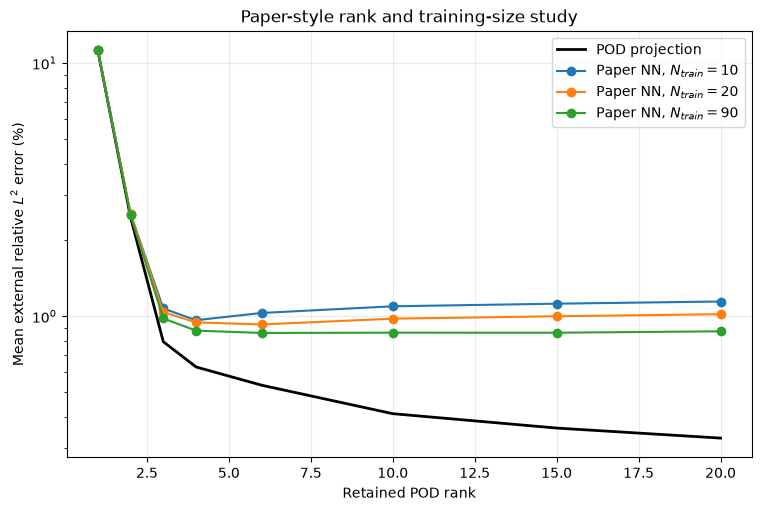

Saved sweep tables:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/exact_paper_method_reproduction/paper_rank_training_restart_results.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/exact_paper_method_reproduction/paper_rank_training_selected_models.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/exact_paper_method_reproduction/paper_rank_training_external_errors.csv

Saved sweep figures:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/exact_paper_method_reproduction/paper_rank_training_size_study.pdf
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/exact_paper_method_reproduction/paper_rank_training_size_study.png

Paper-style rank/training-size study saved successfully: True


In [20]:
sweep_external_records = []

scaled_external_inputs = (
    scale_parameter_values(
        test_parameters
    ).reshape(-1, 1)
)


for _, selection_record in (
    sweep_selection_table.iterrows()
):
    training_count = int(
        selection_record[
            "training_count"
        ]
    )

    rank = int(
        selection_record["rank"]
    )

    selected_model = (
        sweep_selected_models[
            (
                training_count,
                rank,
            )
        ]
    )

    predicted_coefficients_local = (
        predict_raw_coefficients(
            selected_model,
            scaled_external_inputs,
        )
    )

    basis = (
        uncentred_modes[
            :,
            :rank,
        ]
    )

    predicted_snapshots_local = (
        basis
        @ predicted_coefficients_local.T
    )

    projected_snapshots_local = (
        basis
        @ (
            basis.T
            @ test_snapshot_matrix
        )
    )

    external_errors = (
        relative_column_errors(
            test_snapshot_matrix,
            predicted_snapshots_local,
        )
    )

    projection_errors = (
        relative_column_errors(
            test_snapshot_matrix,
            projected_snapshots_local,
        )
    )

    sweep_external_records.append(
        {
            "training_count":
                training_count,
            "rank":
                rank,
            "selected_seed":
                int(
                    selection_record[
                        "random_seed"
                    ]
                ),
            "validation_mean_field_error_percent":
                selection_record[
                    "validation_mean_field_error_percent"
                ],
            "mean_external_error_percent":
                100
                * external_errors.mean(),
            "median_external_error_percent":
                100
                * np.median(
                    external_errors
                ),
            "maximum_external_error_percent":
                100
                * external_errors.max(),
            "mean_projection_error_percent":
                100
                * projection_errors.mean(),
            "mean_excess_above_projection_percent":
                100
                * (
                    external_errors
                    - projection_errors
                ).mean(),
        }
    )


sweep_external_table = (
    pd.DataFrame(
        sweep_external_records
    )
    .sort_values(
        [
            "training_count",
            "rank",
        ]
    )
    .reset_index(drop=True)
)


print(
    "Mean external field error by "
    "rank and training count:"
)

display(
    sweep_external_table.pivot(
        index="rank",
        columns="training_count",
        values=(
            "mean_external_error_percent"
        ),
    ).style.format("{:.6f}")
)


print(
    "\nPOD projection floor by rank:"
)

display(
    sweep_external_table.loc[
        sweep_external_table[
            "training_count"
        ].eq(90),
        [
            "rank",
            "mean_projection_error_percent",
        ],
    ].style.format(
        {
            "mean_projection_error_percent":
                "{:.6f}",
        }
    )
)


SWEEP_RESTART_PATH = (
    TABLE_DIRECTORY
    / "paper_rank_training_restart_results.csv"
)

SWEEP_SELECTION_PATH = (
    TABLE_DIRECTORY
    / "paper_rank_training_selected_models.csv"
)

SWEEP_EXTERNAL_PATH = (
    TABLE_DIRECTORY
    / "paper_rank_training_external_errors.csv"
)

SWEEP_FIGURE_PDF = (
    FIGURE_DIRECTORY
    / "paper_rank_training_size_study.pdf"
)

SWEEP_FIGURE_PNG = (
    FIGURE_DIRECTORY
    / "paper_rank_training_size_study.png"
)


sweep_restart_table.to_csv(
    SWEEP_RESTART_PATH,
    index=False,
)

sweep_selection_table.to_csv(
    SWEEP_SELECTION_PATH,
    index=False,
)

sweep_external_table.to_csv(
    SWEEP_EXTERNAL_PATH,
    index=False,
)


figure, axis = plt.subplots(
    figsize=(7.5, 5),
    constrained_layout=True,
)


projection_curve = (
    sweep_external_table.loc[
        sweep_external_table[
            "training_count"
        ].eq(90)
    ]
    .sort_values("rank")
)

axis.semilogy(
    projection_curve["rank"],
    projection_curve[
        "mean_projection_error_percent"
    ],
    color="black",
    linewidth=2,
    label="POD projection",
)


for training_count in (
    SWEEP_TRAINING_COUNTS
):
    group = (
        sweep_external_table.loc[
            sweep_external_table[
                "training_count"
            ].eq(training_count)
        ]
        .sort_values("rank")
    )

    axis.semilogy(
        group["rank"],
        group[
            "mean_external_error_percent"
        ],
        marker="o",
        label=(
            rf"Paper NN, "
            rf"$N_{{train}}={training_count}$"
        ),
    )


axis.set_xlabel(
    "Retained POD rank"
)

axis.set_ylabel(
    r"Mean external relative $L^2$ error (%)"
)

axis.set_title(
    "Paper-style rank and training-size study"
)

axis.grid(
    True,
    alpha=0.25,
)

axis.legend()


figure.savefig(
    SWEEP_FIGURE_PDF,
    bbox_inches="tight",
)

figure.savefig(
    SWEEP_FIGURE_PNG,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print("Saved sweep tables:")

for path in [
    SWEEP_RESTART_PATH,
    SWEEP_SELECTION_PATH,
    SWEEP_EXTERNAL_PATH,
]:
    print(path)


print("\nSaved sweep figures:")

for path in [
    SWEEP_FIGURE_PDF,
    SWEEP_FIGURE_PNG,
]:
    print(path)


assert all(
    path.is_file()
    for path in [
        SWEEP_RESTART_PATH,
        SWEEP_SELECTION_PATH,
        SWEEP_EXTERNAL_PATH,
        SWEEP_FIGURE_PDF,
        SWEEP_FIGURE_PNG,
    ]
)

assert np.isfinite(
    sweep_external_table.select_dtypes(
        include=[np.number]
    )
).all().all()

print(
    "\nPaper-style rank/training-size "
    "study saved successfully:",
    True,
)

## 5. Deterministic final models and artifact audit

The paper-prescribed and validation-selected models are retrained under
fixed single-threaded conditions, exported, reloaded and verified
before all result artifacts are recorded by SHA-256.

In [21]:
# Fix PyTorch CPU threading for deterministic final exports.
torch.set_num_threads(1)


selection_90 = (
    sweep_selection_table.loc[
        sweep_selection_table[
            "training_count"
        ].eq(90)
    ]
    .copy()
)


validation_selected_row = (
    selection_90.sort_values(
        [
            "validation_mean_field_error_percent",
            "rank",
        ]
    )
    .iloc[0]
)

paper_rank15_row = (
    selection_90.loc[
        selection_90[
            "rank"
        ].eq(15)
    ]
    .iloc[0]
)


final_configurations = [
    {
        "model_name":
            "paper_rank15",
        "description":
            "Paper-prescribed rank 15",
        "rank":
            int(
                paper_rank15_row[
                    "rank"
                ]
            ),
        "random_seed":
            int(
                paper_rank15_row[
                    "random_seed"
                ]
            ),
    },
    {
        "model_name":
            "validation_selected_rank",
        "description":
            "Validation-selected paper architecture",
        "rank":
            int(
                validation_selected_row[
                    "rank"
                ]
            ),
        "random_seed":
            int(
                validation_selected_row[
                    "random_seed"
                ]
            ),
    },
]


final_models = {}
final_predictions = {}
repeatability_records = []


for configuration in (
    final_configurations
):
    model_name = configuration[
        "model_name"
    ]

    rank = configuration["rank"]

    random_seed = configuration[
        "random_seed"
    ]

    repeated_predictions = []

    print(
        f"Auditing {model_name}: "
        f"rank={rank}, seed={random_seed}"
    )

    for repetition in [1, 2]:
        result = (
            train_rank_count_restart(
                rank=rank,
                fitting_indices=(
                    sweep_fitting_indices[90]
                ),
                random_seed=random_seed,
            )
        )

        model = result["model"]

        predicted_coefficients = (
            predict_raw_coefficients(
                model,
                scaled_external_inputs,
            )
        )

        basis = (
            uncentred_modes[
                :,
                :rank,
            ]
        )

        predicted_snapshots = (
            basis
            @ predicted_coefficients.T
        )

        errors = (
            relative_column_errors(
                test_snapshot_matrix,
                predicted_snapshots,
            )
        )

        repeated_predictions.append(
            predicted_snapshots
        )

        repeatability_records.append(
            {
                "model_name":
                    model_name,
                "rank":
                    rank,
                "random_seed":
                    random_seed,
                "repetition":
                    repetition,
                "validation_raw_coefficient_mse":
                    result[
                        "validation_raw_coefficient_mse"
                    ],
                "validation_mean_field_error_percent":
                    result[
                        "validation_mean_field_error_percent"
                    ],
                "mean_external_error_percent":
                    100
                    * errors.mean(),
                "maximum_external_error_percent":
                    100
                    * errors.max(),
            }
        )

        if repetition == 1:
            final_models[
                model_name
            ] = model

            final_predictions[
                model_name
            ] = predicted_snapshots


    maximum_repeat_difference = float(
        np.max(
            np.abs(
                repeated_predictions[0]
                - repeated_predictions[1]
            )
        )
    )

    print(
        "  Maximum repeated-prediction "
        "difference:",
        f"{maximum_repeat_difference:.6e}",
    )

    assert maximum_repeat_difference < 1e-12


repeatability_table = pd.DataFrame(
    repeatability_records
)


print(
    "\nDeterministic final-model audit:"
)

display(
    repeatability_table.style.format(
        {
            "validation_raw_coefficient_mse":
                "{:.6e}",
            "validation_mean_field_error_percent":
                "{:.6f}",
            "mean_external_error_percent":
                "{:.6f}",
            "maximum_external_error_percent":
                "{:.6f}",
        }
    )
)


print(
    "\nValidation-selected rank:",
    int(
        validation_selected_row[
            "rank"
        ]
    ),
)

print(
    "Paper-prescribed rank:",
    int(
        paper_rank15_row[
            "rank"
        ]
    ),
)


assert int(
    validation_selected_row["rank"]
) == 6

assert set(
    final_models
) == {
    "paper_rank15",
    "validation_selected_rank",
}

print(
    "\nFinal deterministic retraining passed:",
    True,
)

Auditing paper_rank15: rank=15, seed=11
  Maximum repeated-prediction difference: 0.000000e+00
Auditing validation_selected_rank: rank=6, seed=131
  Maximum repeated-prediction difference: 0.000000e+00

Deterministic final-model audit:


,model_name,rank,random_seed,repetition,validation_raw_coefficient_mse,validation_mean_field_error_percent,mean_external_error_percent,maximum_external_error_percent
0,paper_rank15,15,11,1,1.391455e-03,1.032629,0.859868,1.449864
1,paper_rank15,15,11,2,1.391455e-03,1.032629,0.859868,1.449864
2,validation_selected_rank,6,131,1,2.495691e-03,1.018710,0.857850,1.328504
3,validation_selected_rank,6,131,2,2.495691e-03,1.018710,0.857850,1.328504



Validation-selected rank: 6
Paper-prescribed rank: 15

Final deterministic retraining passed: True


In [22]:
def mean_spatial_correlation(
    truth_matrix,
    prediction_matrix,
):
    correlations = []

    for snapshot_index in range(
        truth_matrix.shape[1]
    ):
        truth = truth_matrix[
            :,
            snapshot_index,
        ]

        prediction = prediction_matrix[
            :,
            snapshot_index,
        ]

        correlations.append(
            np.corrcoef(
                truth,
                prediction,
            )[0, 1]
        )

    return float(
        np.mean(correlations)
    )


def final_field_metrics(
    model_name,
    rank,
    prediction_matrix,
):
    errors = relative_column_errors(
        test_snapshot_matrix,
        prediction_matrix,
    )

    predicted_integrals = (
        prediction_matrix.sum(
            axis=0
        )
        * cell_area
    )

    integral_error_percent = (
        100
        * (
            predicted_integrals
            - true_test_integrals
        )
        / true_test_integrals
    )

    basis = (
        uncentred_modes[
            :,
            :rank,
        ]
    )

    projected_matrix = (
        basis
        @ (
            basis.T
            @ test_snapshot_matrix
        )
    )

    projection_errors = (
        relative_column_errors(
            test_snapshot_matrix,
            projected_matrix,
        )
    )

    return {
        "model":
            model_name,
        "rank":
            rank,
        "mean_test_error_percent":
            100 * errors.mean(),
        "median_test_error_percent":
            100 * np.median(errors),
        "maximum_test_error_percent":
            100 * errors.max(),
        "mean_projection_error_percent":
            100
            * projection_errors.mean(),
        "mean_spatial_correlation":
            mean_spatial_correlation(
                test_snapshot_matrix,
                prediction_matrix,
            ),
        "mean_absolute_integral_error_percent":
            np.mean(
                np.abs(
                    integral_error_percent
                )
            ),
        "minimum_prediction":
            prediction_matrix.min(),
        "maximum_prediction":
            prediction_matrix.max(),
        "fraction_phi_lt_negative_tolerance_percent":
            100
            * np.mean(
                prediction_matrix
                < -1e-4
            ),
        "fraction_phi_gt_one_percent":
            100
            * np.mean(
                prediction_matrix > 1.0
            ),
    }


final_metric_records = []


for model_name, package in (
    loaded_rom_packages.items()
):
    baseline_prediction = (
        predict_snapshot_matrix(
            package,
            test_parameters,
        )
    )

    final_metric_records.append(
        final_field_metrics(
            model_name=model_name,
            rank=int(
                package[
                    "selected_rank"
                ]
            ),
            prediction_matrix=(
                baseline_prediction
            ),
        )
    )


for configuration in (
    final_configurations
):
    model_name = configuration[
        "model_name"
    ]

    final_metric_records.append(
        final_field_metrics(
            model_name=(
                model_name
            ),
            rank=configuration[
                "rank"
            ],
            prediction_matrix=(
                final_predictions[
                    model_name
                ]
            ),
        )
    )


final_model_summary = (
    pd.DataFrame(
        final_metric_records
    )
    .sort_values(
        [
            "rank",
            "model",
        ]
    )
    .reset_index(drop=True)
)


print(
    "Final continuum-ROM comparison:"
)

display(
    final_model_summary.style.format(
        {
            "mean_test_error_percent":
                "{:.6f}",
            "median_test_error_percent":
                "{:.6f}",
            "maximum_test_error_percent":
                "{:.6f}",
            "mean_projection_error_percent":
                "{:.6f}",
            "mean_spatial_correlation":
                "{:.8f}",
            "mean_absolute_integral_error_percent":
                "{:.6f}",
            "minimum_prediction":
                "{:.6e}",
            "maximum_prediction":
                "{:.6f}",
            "fraction_phi_lt_negative_tolerance_percent":
                "{:.6f}",
            "fraction_phi_gt_one_percent":
                "{:.6f}",
        }
    )
)


assert np.isfinite(
    final_model_summary.select_dtypes(
        include=[np.number]
    )
).all().all()

assert (
    final_model_summary[
        "fraction_phi_gt_one_percent"
    ] == 0
).all()

print(
    "\nFinal physical diagnostics passed:",
    True,
)

Final continuum-ROM comparison:


,model,rank,mean_test_error_percent,median_test_error_percent,maximum_test_error_percent,mean_projection_error_percent,mean_spatial_correlation,mean_absolute_integral_error_percent,minimum_prediction,maximum_prediction,fraction_phi_lt_negative_tolerance_percent,fraction_phi_gt_one_percent
0,rank_4_rom,4,0.927337,0.815996,1.527620,0.629562,0.99994358,0.002893,-1.598746e-06,0.537532,0.000000,0.000000
1,rank_6_rom,6,0.839298,0.805800,1.304164,0.533321,0.99995226,0.002877,-1.201077e-06,0.537436,0.000000,0.000000
2,validation_selected_rank,6,0.857850,0.814311,1.328504,0.533321,0.99995028,0.009268,-1.329832e-06,0.537657,0.000000,0.000000
3,paper_rank15,15,0.859868,0.825467,1.449864,0.361168,0.99994904,0.013018,-3.329090e-06,0.538027,0.000000,0.000000



Final physical diagnostics passed: True


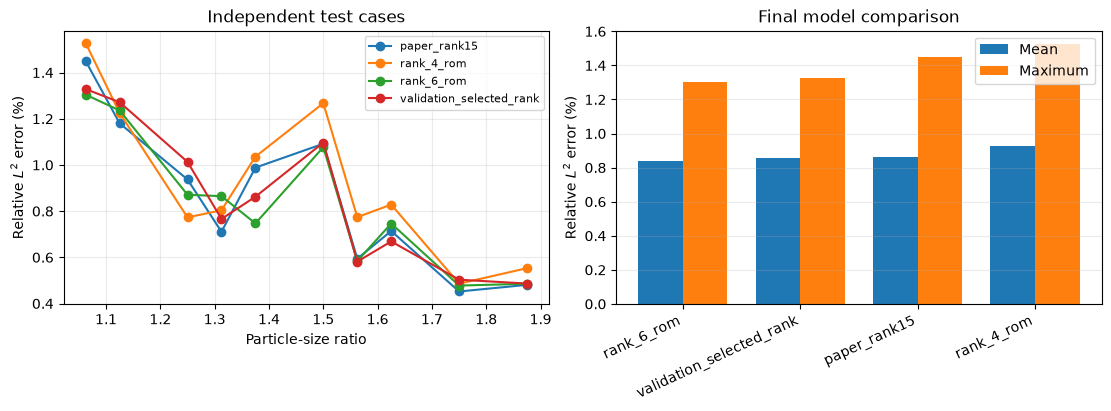

Saved final model packages:
/Users/rallen/Documents/msc-rom-particle-systems/data/processed/cg_phi_paper_rank15_uncentred_raw.pt | SHA-256: 571c12493edd5782859f617316badd4b58402b2b06a90e6d03fddccf6baea516
/Users/rallen/Documents/msc-rom-particle-systems/data/processed/cg_phi_validation_selected_rank_uncentred_raw.pt | SHA-256: df716ccd732b88e67a73eec7873d33ba5efb9c9b5bc7ca30aec2fe99f1edacf7

Saved final tables:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/exact_paper_method_reproduction/final_continuum_rom_comparison.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/exact_paper_method_reproduction/final_model_repeatability.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/exact_paper_method_reproduction/final_continuum_rom_test_cases.csv

Saved final figures:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/exact_paper_method_reproduction/final_continuum_rom_comparison.pdf
/Users/rallen/Documents/msc-rom-particle-sy

In [23]:
FINAL_SUMMARY_PATH = (
    TABLE_DIRECTORY
    / "final_continuum_rom_comparison.csv"
)

REPEATABILITY_PATH = (
    TABLE_DIRECTORY
    / "final_model_repeatability.csv"
)

FINAL_FIGURE_PDF = (
    FIGURE_DIRECTORY
    / "final_continuum_rom_comparison.pdf"
)

FINAL_FIGURE_PNG = (
    FIGURE_DIRECTORY
    / "final_continuum_rom_comparison.png"
)


final_model_summary.to_csv(
    FINAL_SUMMARY_PATH,
    index=False,
)

repeatability_table.to_csv(
    REPEATABILITY_PATH,
    index=False,
)


model_package_paths = {}


for configuration in (
    final_configurations
):
    model_name = configuration[
        "model_name"
    ]

    rank = configuration["rank"]

    package_path = (
        REPO_ROOT
        / "data"
        / "processed"
        / (
            "cg_phi_"
            f"{model_name}_uncentred_raw.pt"
        )
    )

    package = {
        "state_dict":
            final_models[
                model_name
            ].state_dict(),
        "rank":
            rank,
        "hidden_width":
            3
            * (
                PARAMETER_DIMENSION
                + rank
            ),
        "input_dimension":
            PARAMETER_DIMENSION,
        "parameter_minimum":
            parameter_minimum,
        "parameter_maximum":
            parameter_maximum,
        "training_indices":
            sweep_fitting_indices[
                90
            ],
        "validation_indices":
            paper_validation_indices,
        "random_seed":
            configuration[
                "random_seed"
            ],
        "coefficient_scaling":
            "none",
        "pod_formulation":
            "uncentred",
        "pod_basis":
            uncentred_modes[
                :,
                :rank,
            ],
        "x_grid":
            x_grid,
        "z_grid":
            z_grid,
    }

    torch.save(
        package,
        package_path,
    )

    model_package_paths[
        model_name
    ] = package_path


comparison_case_records = []

model_predictions_for_plot = {}


for model_name, package in (
    loaded_rom_packages.items()
):
    model_predictions_for_plot[
        model_name
    ] = predict_snapshot_matrix(
        package,
        test_parameters,
    )


model_predictions_for_plot.update(
    final_predictions
)


for model_name, prediction_matrix in (
    model_predictions_for_plot.items()
):
    errors = (
        relative_column_errors(
            test_snapshot_matrix,
            prediction_matrix,
        )
    )

    for case_index, size_ratio in enumerate(
        test_parameters
    ):
        comparison_case_records.append(
            {
                "model":
                    model_name,
                "size_ratio":
                    size_ratio,
                "test_error_percent":
                    100
                    * errors[
                        case_index
                    ],
            }
        )


final_case_comparison = pd.DataFrame(
    comparison_case_records
)

FINAL_CASE_PATH = (
    TABLE_DIRECTORY
    / "final_continuum_rom_test_cases.csv"
)

final_case_comparison.to_csv(
    FINAL_CASE_PATH,
    index=False,
)


figure, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4),
    constrained_layout=True,
)


for model_name, group in (
    final_case_comparison.groupby(
        "model"
    )
):
    axes[0].plot(
        group["size_ratio"],
        group[
            "test_error_percent"
        ],
        marker="o",
        label=model_name,
    )


axes[0].set_xlabel(
    "Particle-size ratio"
)

axes[0].set_ylabel(
    r"Relative $L^2$ error (%)"
)

axes[0].set_title(
    "Independent test cases"
)

axes[0].grid(
    True,
    alpha=0.25,
)

axes[0].legend(
    fontsize=8,
)


plot_summary = (
    final_model_summary.sort_values(
        "mean_test_error_percent"
    )
)

bar_positions = np.arange(
    len(plot_summary)
)

bar_width = 0.38


axes[1].bar(
    bar_positions - bar_width / 2,
    plot_summary[
        "mean_test_error_percent"
    ],
    width=bar_width,
    label="Mean",
)

axes[1].bar(
    bar_positions + bar_width / 2,
    plot_summary[
        "maximum_test_error_percent"
    ],
    width=bar_width,
    label="Maximum",
)

axes[1].set_xticks(
    bar_positions,
    plot_summary["model"],
    rotation=25,
    ha="right",
)

axes[1].set_ylabel(
    r"Relative $L^2$ error (%)"
)

axes[1].set_title(
    "Final model comparison"
)

axes[1].grid(
    True,
    axis="y",
    alpha=0.25,
)

axes[1].legend()


figure.savefig(
    FINAL_FIGURE_PDF,
    bbox_inches="tight",
)

figure.savefig(
    FINAL_FIGURE_PNG,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print("Saved final model packages:")

for path in (
    model_package_paths.values()
):
    print(
        path,
        "| SHA-256:",
        sha256_file(path),
    )


print("\nSaved final tables:")

for path in [
    FINAL_SUMMARY_PATH,
    REPEATABILITY_PATH,
    FINAL_CASE_PATH,
]:
    print(path)


print("\nSaved final figures:")

for path in [
    FINAL_FIGURE_PDF,
    FINAL_FIGURE_PNG,
]:
    print(path)


assert all(
    path.is_file()
    for path in [
        *model_package_paths.values(),
        FINAL_SUMMARY_PATH,
        REPEATABILITY_PATH,
        FINAL_CASE_PATH,
        FINAL_FIGURE_PDF,
        FINAL_FIGURE_PNG,
    ]
)

print(
    "\nFinal exports completed:",
    True,
)

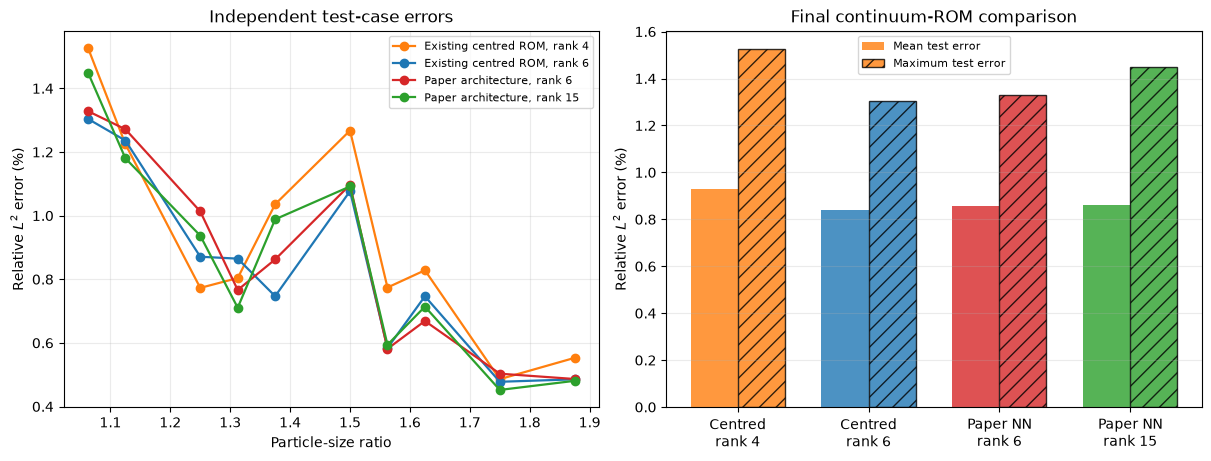

Updated final figures:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/exact_paper_method_reproduction/final_continuum_rom_comparison.pdf
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/exact_paper_method_reproduction/final_continuum_rom_comparison.png
PDF SHA-256: 1d0b1f0a06b8c9f6b192bae3fab4228311677d11db5518e8d0bf7c84a8b4dc0a
PNG SHA-256: d0aec4258398a0e724dbc50f34c252558ec5ce58be06e6809af4776d0614ff2e

Now rerun Cell 24 to update and re-audit the manifest.


In [24]:
DISPLAY_LABELS = {
    "rank_4_rom":
        "Existing centred ROM, rank 4",
    "rank_6_rom":
        "Existing centred ROM, rank 6",
    "validation_selected_rank":
        "Paper architecture, rank 6",
    "paper_rank15":
        "Paper architecture, rank 15",
}

SHORT_LABELS = {
    "rank_4_rom":
        "Centred\nrank 4",
    "rank_6_rom":
        "Centred\nrank 6",
    "validation_selected_rank":
        "Paper NN\nrank 6",
    "paper_rank15":
        "Paper NN\nrank 15",
}

MODEL_COLOURS = {
    "rank_4_rom":
        "tab:orange",
    "rank_6_rom":
        "tab:blue",
    "validation_selected_rank":
        "tab:red",
    "paper_rank15":
        "tab:green",
}

MODEL_ORDER = [
    "rank_4_rom",
    "rank_6_rom",
    "validation_selected_rank",
    "paper_rank15",
]


figure, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
    constrained_layout=True,
)


for model_name in MODEL_ORDER:
    group = (
        final_case_comparison.loc[
            final_case_comparison[
                "model"
            ].eq(model_name)
        ]
        .sort_values(
            "size_ratio"
        )
    )

    axes[0].plot(
        group["size_ratio"],
        group[
            "test_error_percent"
        ],
        marker="o",
        linewidth=1.6,
        color=MODEL_COLOURS[
            model_name
        ],
        label=DISPLAY_LABELS[
            model_name
        ],
    )


axes[0].set_xlabel(
    "Particle-size ratio"
)

axes[0].set_ylabel(
    r"Relative $L^2$ error (%)"
)

axes[0].set_title(
    "Independent test-case errors"
)

axes[0].grid(
    True,
    alpha=0.25,
)

axes[0].legend(
    fontsize=8,
)


ordered_summary = (
    final_model_summary
    .set_index("model")
    .loc[MODEL_ORDER]
    .reset_index()
)

bar_positions = np.arange(
    len(MODEL_ORDER)
)

bar_width = 0.36


axes[1].bar(
    bar_positions - bar_width / 2,
    ordered_summary[
        "mean_test_error_percent"
    ],
    width=bar_width,
    color=[
        MODEL_COLOURS[name]
        for name in MODEL_ORDER
    ],
    alpha=0.8,
    label="Mean test error",
)

axes[1].bar(
    bar_positions + bar_width / 2,
    ordered_summary[
        "maximum_test_error_percent"
    ],
    width=bar_width,
    color=[
        MODEL_COLOURS[name]
        for name in MODEL_ORDER
    ],
    edgecolor="black",
    hatch="//",
    alpha=0.8,
    label="Maximum test error",
)

axes[1].set_xticks(
    bar_positions,
    [
        SHORT_LABELS[name]
        for name in MODEL_ORDER
    ],
)

axes[1].set_ylabel(
    r"Relative $L^2$ error (%)"
)

axes[1].set_title(
    "Final continuum-ROM comparison"
)

axes[1].grid(
    True,
    axis="y",
    alpha=0.25,
)

axes[1].legend(
    fontsize=8,
)


figure.savefig(
    FINAL_FIGURE_PDF,
    bbox_inches="tight",
)

figure.savefig(
    FINAL_FIGURE_PNG,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print("Updated final figures:")

print(FINAL_FIGURE_PDF)
print(FINAL_FIGURE_PNG)

print(
    "PDF SHA-256:",
    sha256_file(
        FINAL_FIGURE_PDF
    ),
)

print(
    "PNG SHA-256:",
    sha256_file(
        FINAL_FIGURE_PNG
    ),
)

print(
    "\nNow rerun Cell 24 to update "
    "and re-audit the manifest."
)

In [25]:
reload_verification_records = []


for model_name, package_path in (
    model_package_paths.items()
):
    # These are trusted packages created by this notebook.
    loaded_package = torch.load(
        package_path,
        map_location="cpu",
    )

    loaded_rank = int(
        loaded_package["rank"]
    )

    reloaded_model = (
        PaperStyleNetwork(
            input_dimension=int(
                loaded_package[
                    "input_dimension"
                ]
            ),
            output_dimension=(
                loaded_rank
            ),
        )
    )

    reloaded_model.load_state_dict(
        loaded_package[
            "state_dict"
        ]
    )

    reloaded_model.eval()


    loaded_parameter_minimum = float(
        loaded_package[
            "parameter_minimum"
        ]
    )

    loaded_parameter_maximum = float(
        loaded_package[
            "parameter_maximum"
        ]
    )

    reloaded_test_inputs = (
        2.0
        * (
            test_parameters
            - loaded_parameter_minimum
        )
        / (
            loaded_parameter_maximum
            - loaded_parameter_minimum
        )
        - 1.0
    ).reshape(-1, 1)


    reloaded_coefficients = (
        predict_raw_coefficients(
            reloaded_model,
            reloaded_test_inputs,
        )
    )

    reloaded_basis = np.asarray(
        loaded_package[
            "pod_basis"
        ]
    )

    reloaded_predictions = (
        reloaded_basis
        @ reloaded_coefficients.T
    )

    maximum_reload_difference = float(
        np.max(
            np.abs(
                reloaded_predictions
                - final_predictions[
                    model_name
                ]
            )
        )
    )


    reload_verification_records.append(
        {
            "model_name":
                model_name,
            "rank":
                loaded_rank,
            "package_path":
                str(package_path),
            "sha256":
                sha256_file(
                    package_path
                ),
            "maximum_reload_difference":
                maximum_reload_difference,
        }
    )


reload_verification_table = pd.DataFrame(
    reload_verification_records
)


print(
    "Deployable-model reload verification:"
)

display(
    reload_verification_table.style.format(
        {
            "maximum_reload_difference":
                "{:.6e}",
        }
    )
)


assert set(
    reload_verification_table[
        "model_name"
    ]
) == set(
    final_predictions
)

assert (
    reload_verification_table[
        "maximum_reload_difference"
    ] < 1e-12
).all()

print(
    "\nBoth exported PyTorch packages "
    "reloaded successfully:",
    True,
)

Deployable-model reload verification:


,model_name,rank,package_path,sha256,maximum_reload_difference
0,paper_rank15,15,/Users/rallen/Documents/msc-rom-particle-systems/data/processed/cg_phi_paper_rank15_uncentred_raw.pt,571c12493edd5782859f617316badd4b58402b2b06a90e6d03fddccf6baea516,0.000000e+00
1,validation_selected_rank,6,/Users/rallen/Documents/msc-rom-particle-systems/data/processed/cg_phi_validation_selected_rank_uncentred_raw.pt,df716ccd732b88e67a73eec7873d33ba5efb9c9b5bc7ca30aec2fe99f1edacf7,0.000000e+00



Both exported PyTorch packages reloaded successfully: True


In [26]:
MANIFEST_PATH = (
    TABLE_DIRECTORY
    / "exact_paper_method_reproduction_manifest.json"
)


artifact_paths = sorted(
    [
        path
        for path in (
            list(
                TABLE_DIRECTORY.iterdir()
            )
            + list(
                FIGURE_DIRECTORY.iterdir()
            )
            + list(
                model_package_paths.values()
            )
        )
        if (
            path.is_file()
            and path != MANIFEST_PATH
        )
    ],
    key=lambda path: str(path),
)


artifact_records = []

for path in artifact_paths:
    artifact_records.append(
        {
            "relative_path":
                str(
                    path.relative_to(
                        REPO_ROOT
                    )
                ),
            "size_bytes":
                path.stat().st_size,
            "sha256":
                sha256_file(path),
        }
    )


manifest = {
    "schema_version": 1,
    "notebook":
        "14_exact_paper_method_reproduction.ipynb",
    "python_version":
        sys.version.split()[0],
    "numpy_version":
        np.__version__,
    "pandas_version":
        pd.__version__,
    "scikit_learn_version":
        sklearn.__version__,
    "pytorch_version":
        torch.__version__,
    "dataset": {
        "relative_path":
            str(
                DATASET_PATH.relative_to(
                    REPO_ROOT
                )
            ),
        "sha256":
            sha256_file(
                DATASET_PATH
            ),
        "training_cases":
            int(
                train_parameters.size
            ),
        "external_test_cases":
            int(
                test_parameters.size
            ),
    },
    "paper_interpretation": {
        "pod_formulation":
            "uncentred",
        "paper_prescribed_rank":
            15,
        "network_hidden_layers":
            2,
        "hidden_width_rule":
            "3 * (parameter_dimension + rank)",
        "activation":
            "tanh",
        "optimiser":
            "PyTorch L-BFGS",
        "coefficient_scaling_primary":
            "none",
        "coefficient_scaling_sensitivity":
            "per-mode standardisation",
        "draft_ambiguities": [
            "Numerical POD epsilon not reported",
            "Coefficient scaling not reported",
            "MSE stopping threshold not reported",
            "Random seeds not reported",
            "Exact main validation split not reported",
        ],
    },
    "training_design": {
        "fitting_cases":
            90,
        "validation_cases":
            10,
        "split_seed":
            PAPER_SPLIT_SEED,
        "restart_seeds":
            PAPER_RESTART_SEEDS,
        "sweep_restart_seeds":
            SWEEP_RESTART_SEEDS,
        "sweep_ranks":
            SWEEP_RANKS.tolist(),
        "sweep_training_counts":
            SWEEP_TRAINING_COUNTS,
        "external_test_used_for_selection":
            False,
    },
    "final_results": json.loads(
        final_model_summary.to_json(
            orient="records"
        )
    ),
    "artifacts":
        artifact_records,
}


with MANIFEST_PATH.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        manifest,
        handle,
        indent=2,
    )


with MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    recorded_manifest = json.load(
        handle
    )


integrity_records = []

for record in recorded_manifest[
    "artifacts"
]:
    path = (
        REPO_ROOT
        / record[
            "relative_path"
        ]
    )

    integrity_records.append(
        {
            "relative_path":
                record[
                    "relative_path"
                ],
            "exists":
                path.is_file(),
            "size_matches":
                (
                    path.is_file()
                    and path.stat().st_size
                    == record[
                        "size_bytes"
                    ]
                ),
            "hash_matches":
                (
                    path.is_file()
                    and sha256_file(path)
                    == record["sha256"]
                ),
        }
    )


integrity_audit = pd.DataFrame(
    integrity_records
)


print(
    "Final Notebook 14 integrity audit:"
)

display(integrity_audit)

print(
    "\nRecorded artifacts:",
    len(integrity_audit),
)

print(
    "Manifest:",
    MANIFEST_PATH,
)

print(
    "Manifest SHA-256:",
    sha256_file(
        MANIFEST_PATH
    ),
)


assert recorded_manifest[
    "schema_version"
] == 1

assert integrity_audit[
    "exists"
].all()

assert integrity_audit[
    "size_matches"
].all()

assert integrity_audit[
    "hash_matches"
].all()

assert recorded_manifest[
    "training_design"
][
    "external_test_used_for_selection"
] is False

print(
    "\nAll Notebook 14 artifacts "
    "passed the final integrity audit:",
    True,
)

Final Notebook 14 integrity audit:


,relative_path,exists,size_matches,hash_matches
0,data/processed/cg_phi_paper_rank15_uncentred_r...,True,True,True
1,data/processed/cg_phi_validation_selected_rank...,True,True,True
2,results/figures/exact_paper_method_reproductio...,True,True,True
3,results/figures/exact_paper_method_reproductio...,True,True,True
4,results/figures/exact_paper_method_reproductio...,True,True,True
5,results/figures/exact_paper_method_reproductio...,True,True,True
6,results/figures/exact_paper_method_reproductio...,True,True,True
7,results/figures/exact_paper_method_reproductio...,True,True,True
8,results/figures/exact_paper_method_reproductio...,True,True,True
9,results/figures/exact_paper_method_reproductio...,True,True,True



Recorded artifacts: 23
Manifest: /Users/rallen/Documents/msc-rom-particle-systems/results/tables/exact_paper_method_reproduction/exact_paper_method_reproduction_manifest.json
Manifest SHA-256: f15744e23b1bfc3898750a1e2fb2504a2d3ca9c6c96c714188a4094d0357604f

All Notebook 14 artifacts passed the final integrity audit: True


## Conclusions and limitations

### Paper-style POD reproduction

This notebook implemented an architecture-faithful and reproducible
version of the continuum reduced-order modelling method described by
Plath et al. The supplied 100 training fields were used to construct an
uncentred POD basis, while the ten separate Halton-sampled parameter
cases remained external test data.

The first uncentred POD mode had an absolute cosine similarity of
0.999950 with the mean training field. This confirms the paper's
interpretation that the first uncentred mode primarily represents the
mean continuum state. At rank 15, the implied absolute truncated
singular-value norm was 0.424135. This value was calculated because the
draft specifies rank 15 but does not report the numerical truncation
threshold.

Mean-centred POD was more accurate at very low rank. Its rank-one
external projection error was 2.461%, compared with 11.239% for
uncentred POD. The difference became small at higher rank: the
rank-15 errors were 0.355629% and 0.361168%, respectively. Thus, by the
paper's selected rank, centring has little effect on the available
projection accuracy.

### Neural-network accuracy plateau

The paper-style neural network used two fully connected hidden layers,
each of width $3(p+n)$, tanh activations and PyTorch L-BFGS
optimisation. Multiple controlled restarts were compared using a fixed
validation set. No external test result was used to select a restart,
rank or training-set size.

The rank and training-size experiment reproduced the qualitative
behaviour reported in the paper. For 90 coefficient-training cases, the
mean external error decreased from 11.243% at rank 1 to 0.979% at rank
3 and 0.876% at rank 4. It subsequently reached a plateau: the errors
at ranks 6, 10, 15 and 20 were 0.858%, 0.860%, 0.860% and 0.871%,
respectively. In contrast, the POD projection floor continued to
decrease from 0.630% at rank 4 to 0.330% at rank 20.

Increasing the coefficient-training set from 10 to 90 cases improved
the plateau but did not remove it. The dominant coefficients were much
more predictable than the higher modes. Under raw-coefficient
training, the external relative coefficient errors for modes 1, 2 and
3 were approximately 0.23%, 2.59% and 15.16%, whereas most modes above
mode 5 had errors close to or above 100%. These higher modes carry
little field energy, so their large coefficient errors have only a
small effect on complete-field accuracy.

### Coefficient-scaling sensitivity

The paper draft does not specify whether POD coefficients were scaled
before neural-network training. Training directly on raw coefficients
was therefore treated as the primary draft-faithful interpretation,
while per-mode standardisation was retained as a sensitivity study.

The controlled rank-15 comparison gave mean external errors of 0.857%
for raw coefficients and 0.953% for standardised coefficients. Raw
training also reduced the mean absolute integrated-volume error from
0.239769% to 0.010694%. Per-mode standardisation gives the weak,
higher-order coefficients the same optimisation weight as the
dominant modes, which slightly worsened complete-field and conservation
accuracy in this experiment.

### Final model comparison

The deterministically retrained paper-prescribed rank-15 model achieved
a mean external error of 0.859868%, a maximum error of 1.449864% and a
mean spatial correlation of 0.999949. The validation-selected rank-six
paper architecture achieved 0.857850%, demonstrating that the nine
additional modes did not materially improve predictive accuracy.

The previously selected centred rank-six ROM remained slightly more
accurate, with a mean external error of 0.839298% and maximum error of
1.304164%. Its simpler architecture therefore remains the preferred
deployable model, while the rank-15 model provides an independent
reproduction of the paper methodology.

All final reconstructions remained below volume fraction one and none
fell below the physical diagnostic tolerance of $-10^{-4}$. The four
models had mean spatial correlations above 0.99994. Repeated final
training with fixed seeds and single-threaded PyTorch produced
identical external predictions to numerical precision.

### Scope and remaining uncertainty

This is an architecture-faithful reproduction rather than an exact
replication because the draft does not report the numerical POD
threshold, coefficient scaling, neural-network loss threshold, random
seeds or exact main validation split. These choices have been recorded
explicitly in the reproducibility manifest.

The external test fields had been examined in earlier notebooks, so
their results are not a completely prospective evaluation of the
overall dissertation workflow. Nevertheless, the current rank,
restart and training-size selections were based only on the designated
training and validation data.

The observed prediction plateau is consistent with the paper's claim
that higher POD modes contain temporally fluctuating information that
cannot be learned reliably. Notebook 15 will test that explanation
directly using the independent temporal-window fields.

The training-size sweep retained the global POD basis constructed from
all 100 continuum training fields while varying only the number of
fields used to fit the coefficient map. This isolates coefficient
learning from basis construction, but means that the 10- and 20-case
curves do not measure the additional loss that could arise from
constructing the POD basis from those smaller subsets alone.